# 물류 및 공급망 데이터셋 탐색

**코스 모듈:** Module 8
**대상:** 모델이나 지식 그래프를 구축하기 전에 실제 물류 원격 측정(telemetry) 데이터를 이해하고 싶은 초급 학습자

## 코스 설명

현대 공급망은 **연속적인 데이터 스트림**을 생성합니다: 차량 GPS, 창고 재고, 교통, 날씨, 공급업체 성과, 위험 점수 등. 머신러닝이나 그래프 분석을 적용하기 전에 **각 필드의 의미**와 **변수 간 관계**를 알아야 합니다.

이 실습 코스에서는 다음을 수행합니다:

1. **Dynamic Supply Chain Logistics** CSV 데이터셋을 로드하고 검사합니다.
2. 운영 도메인별로 **모든 열의 비즈니스 의미**를 학습합니다.
3. **탐색적 시각화**로 분포, 추세, 관계를 확인합니다.
4. 이 데이터가 예측 및 최적화 워크플로를 지원하는 **실무 사용 사례**를 검토합니다.

> **언어:** 이 노트북의 안내 텍스트는 **한국어**입니다. 기술 용어는 필요 시 영어를 병기합니다.

### 이 노트북 사용법

1. 아래 **코드** 셀을 실행하기 전에 **모든 마크다운** 셀을 읽으세요.
2. Step 0부터 **순서대로** 셀을 실행하세요.
3. 각 플롯이나 테이블 후 **해석** 마크다운을 읽으세요.
4. 코드 셀은 의도적으로 **짧게** 작성되었습니다. 마크다운이 *이유*, *방법*, *주목할 점*을 설명합니다.
5. 플롯은 인라인으로 표시됩니다 — 그림이 비어 있으면 셀을 다시 실행하거나 `%matplotlib inline`이 활성화되어 있는지 확인하세요.


## 사전 요구 사항

| Skill | 필요한 이유 |
|-------|-----------------|
| Basic Python | 노트북 셀 실행 |
| pandas 기초 | `read_csv`, `describe`, 그룹화 |
| (도움이 되는) 물류 용어 | 트럭, 창고, lead time, ETA |

### 데이터셋

| File | 설명 |
|------|-------------|
| `data/logistics-supply-chain/dynamic_supply_chain_logistics_dataset.csv` | 시간별 물류 원격 측정 데이터(Kaggle, CC0-1.0) |

**출처:** [Kaggle — Logistics and supply chain dataset](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset)

- **행 수:** 약 32,000개의 시간별 관측치
- **기간:** 2021년 1월 — 2024년 8월
- **세분성:** 타임스탬프당 1행(시뮬레이션된 차량/네트워크 스냅샷)

## 코스 개요

| Part | 주제 | 학습 목표 |
|------|--------|---------------|
| **0** | 환경 설정 | 라이브러리 설치 및 CSV 위치 확인 |
| **1** | 데이터 로드 | shape, 열, 타입 확인 |
| **2** | 필드 사전 | 도메인별 모든 열 이해 |
| **3** | 데이터 품질 | 결측값 및 범위 확인 |
| **4** | 시간 패턴 | 시간대·월별 활동 변화 확인 |
| **5** | 위치 및 이동 | GPS 커버리지 및 연료 사용량 |
| **6** | 교통, ETA 및 지연 | 혼잡과 배송 편차 연결 |
| **7** | 창고 및 이행(fulfillment) | 재고 vs 수요 신호 |
| **8** | 날씨 및 항만 | 외부 중단 요인 |
| **9** | 공급업체 및 비용 | 상류(upstream) 신뢰성 및 경제성 |
| **10** | IoT, 화물 및 경로 | 콜드체인 및 경로 위험 |
| **11** | 운전자 및 피로 점수 | 인적 요인 모니터링 |
| **12** | 위험 및 분류 | ML용 타깃 변수 |
| **13** | 상관관계 개요 | 함께 움직이는 지표 |
| **14** | 사용 사례(읽기) | 실무에서 이 데이터셋의 활용 |
| **15** | 마무리 | Module 8 다음 단계 |


---

# Step 0 — 환경 설정

데이터를 탐색하기 전에 재현 가능한 Python 환경을 준비합니다. 이 파트에는 아직 **물류 분석이 없습니다** — 도구 설정만 합니다. 설정 셀을 건너뛰면 나중에 혼란스러운 `ModuleNotFoundError`가 발생할 수 있습니다.


### Step 0a — Python 패키지 설치

**이 셀이 하는 일:** pip로 데이터 로드 및 시각화 라이브러리를 설치합니다.

| Package | 이 코스에서의 역할 |
|---------|---------------------|
| `pandas` | CSV 로드, 통계 계산, 시간별 그룹화 |
| `matplotlib` | 선 그래프, 히스토그램, 막대 그래프 |
| `seaborn` | 회귀 플롯, 히트맵, 스타일 scatter plot |
| `cartopy` | 북미 지도 배경 및 투영 GPS scatter plot(Part 5) |

**실행 시점:** 가상 환경(conda, venv 또는 시스템 Python)당 한 번.

**예상 출력:** pip가 아무것도 출력하지 않을 수 있습니다(`-q` quiet 모드). 정상입니다.

> **문제 해결:** pip로 `cartopy` 설치가 실패하면 `conda install -c conda-forge cartopy`를 시도하세요.
> 다른 오류가 나면 코스 가상 환경을 활성화한 뒤 다시 실행하세요.


In [1]:
# Step 0a — Install dependencies (run once per environment)
%pip install -q pandas matplotlib seaborn cartopy


Note: you may need to restart the kernel to use updated packages.


### Step 0b — 라이브러리 import 및 플롯 스타일 설정

**이 셀이 하는 일:** 핵심 라이브러리를 import하고 노트북 전체의 표시 기본값을 설정합니다.

**주요 동작 설명:**

| Line | 목적 |
|------|---------|
| `sns.set_theme(...)` | 모든 seaborn 플롯에 일관된 색상과 격자 |
| `plt.rcParams['figure.figsize']` | 크기 조정 없이 읽기 쉬운 기본 플롯 크기 |
| `pd.set_option('display.max_columns', None)` | 테이블 미리보기 시 26개 열 모두 표시 |
| `pd.set_option('display.float_format', ...)` | 더 깔끔한 테이블을 위해 float를 소수 3자리로 반올림 |

**예상 출력:** `라이브러리 로드 완료.`

> **참고:** `pathlib`의 `Path`는 Windows, macOS, Linux에서 동작하는 파일 경로를 만드는 데 도움이 됩니다.


In [2]:
# Step 0b — Imports and display settings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print('라이브러리 로드 완료.')


라이브러리 로드 완료.


**Step 0b 실행 후:** 아직 플롯은 없습니다. 성공 메시지가 출력되었는지 확인하세요. `ModuleNotFoundError`가 보이면 Step 0a로 돌아가세요.


### Step 0c — 데이터셋 경로 확인

**이 셀이 하는 일:** `Module_8/`을 찾고 CSV 파일의 절대 경로를 구성합니다.

**경로 로직이 중요한 이유:** Jupyter는 저장소 루트 *또는* `Module_8/` 내부에서 시작할 수 있습니다. `if not ...` 블록은 상위 폴더에서 노트북을 연 경우를 감지하고 `MODULE_DIR`을 자동으로 조정합니다.

**재사용할 변수:**

| Variable | 의미 |
|----------|---------|
| `MODULE_DIR` | Module 8 실습 루트 폴더 |
| `DATA_PATH` | 물류 CSV 전체 경로 |

**예상 출력:**

- `파일 존재 여부: True` — 데이터 로드 준비 완료.
- `파일 존재 여부: False` — `data/DATASETS.md`에 따라 CSV를 다운로드하세요.


In [3]:
# Step 0c — Dataset path
MODULE_DIR = Path('.').resolve()
if not (MODULE_DIR / 'data').exists() and (MODULE_DIR.parent / 'Module_8' / 'data').exists():
    MODULE_DIR = MODULE_DIR.parent / 'Module_8'

DATA_PATH = MODULE_DIR / 'data' / 'logistics-supply-chain' / 'dynamic_supply_chain_logistics_dataset.csv'
print(f'모듈 디렉터리: {MODULE_DIR}')
print(f'데이터셋 경로:     {DATA_PATH}')
print(f'파일 존재 여부:      {DATA_PATH.exists()}')


모듈 디렉터리: /home/ethan/newgen/KMOU_Course/Module_8
데이터셋 경로:     /home/ethan/newgen/KMOU_Course/Module_8/data/logistics-supply-chain/dynamic_supply_chain_logistics_dataset.csv
파일 존재 여부:      True


**Step 0c 실행 후:** `파일 존재 여부`가 `False`이면 여기서 중단하고 데이터셋을 다운로드하세요. CSV가 디스크에 있을 때까지 Part 1로 진행하지 마세요.


---

# Part 1 — 데이터셋 로드

이제 CSV를 pandas **DataFrame** `df`로 읽습니다. 이것이 노트북의 중심 객체입니다. 아래의 모든 차트와 테이블은 `df`에서 읽습니다.


### Step 1a — CSV를 DataFrame으로 읽기

**이 셀이 하는 일:**

1. `pd.read_csv(DATA_PATH)` — 디스크에서 모든 행과 열을 로드합니다.
2. `pd.to_datetime(df['timestamp'])` — timestamp 열을 텍스트에서 datetime으로 변환합니다.
3. 행 수, 열 수, 가장 이른/늦은 타임스탬프를 출력합니다.

**주목할 점:**

- 각 행은 물류 운영의 **시간별 스냅샷**입니다.
- 차량, 창고, 공급업체, 위험, 결과를 아우르는 **26개 열**이 있습니다.
- 날짜 범위는 대략 **2021-01-01**부터 **2024-08-29**까지입니다.

**예상 출력:**

```
행 수:    32,065
열 수: 26
날짜 범위: 2021-01-01 00:00:00 → 2024-08-29 00:00:00
```


In [4]:
# Step 1a — Load CSV
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'행 수:    {len(df):,}')
print(f'열 수: {len(df.columns)}')
print(f'날짜 범위: {df["timestamp"].min()} → {df["timestamp"].max()}')


행 수:    32,065
열 수: 26
날짜 범위: 2021-01-01 00:00:00 → 2024-08-29 00:00:00


**Step 1a 해석 방법:**

- **32,065행**은 약 3.7년치 시간별 기록을 의미합니다(이 합성 데이터셋에서는 일부 시간이 차량/지역에 걸쳐 반복될 수 있음).
- **26개 열**은 상대적으로 넓습니다 — IoT + ERP + TMS가 병합된 내보내기에서 흔합니다.
- `timestamp`를 일찍 파싱하면 Part 4의 시간 기반 플롯을 사용할 수 있습니다.


### Step 1b — 처음 몇 행 미리보기

**이 셀이 하는 일:** `df.head()` — 처음 5행 — 을 대화형 테이블로 표시합니다.

**미리보기 읽는 방법:**

| Question | 확인할 열 |
|----------|-----------------|
| 차량 위치는? | `vehicle_gps_latitude`, `vehicle_gps_longitude` |
| 재고가 부족한가? | `warehouse_inventory_level` vs `historical_demand` |
| 이 시간대가 위험한가? | `risk_classification`, `delay_probability` |
| 외부 스트레스가 있는가? | `traffic_congestion_level`, `weather_condition_severity` |

**예상 출력:** 5행 테이블. Jupyter 테마에서 열이 잘리면 가로로 스크롤하세요.


In [5]:
# Step 1b — Head preview
df.head()


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.376,-77.014,5.137,4.998,5.928,985.717,4.951,0.481,0.761,0.359,4.289,456.504,0.986,2.128,100.773,0.574,0.777,1.182,0.502,0.034,0.979,0.506,0.885,Moderate Risk,9.111
1,2021-01-01 01:00:00,33.508,-117.037,5.102,0.985,1.592,396.700,1.030,0.621,0.197,0.231,7.018,640.408,0.463,12.608,"5,313.738",-9.753,0.092,9.612,0.967,0.202,0.919,0.981,0.544,High Risk,8.175
2,2021-01-01 02:00:00,30.021,-75.269,5.091,4.973,8.788,832.409,4.220,0.811,0.153,0.027,9.605,155.749,0.599,14.124,"1,595.049",-6.491,0.254,6.570,0.946,0.264,0.394,0.999,0.803,High Risk,1.284
3,2021-01-01 03:00:00,36.649,-70.191,8.220,3.095,0.045,0.573,0.530,0.009,0.812,0.617,8.900,104.318,0.743,3.819,"2,530.432",-0.151,0.878,0.549,4.674,0.363,0.905,0.993,0.026,High Risk,9.305
4,2021-01-01 04:00:00,30.001,-70.012,5.000,3.216,8.005,914.925,3.621,0.020,0.054,0.952,0.062,977.223,0.431,14.001,"2,146.190",2.429,0.262,8.861,3.445,0.017,0.259,0.912,0.991,High Risk,7.752


**Step 1b 후 — 성찰 질문:**

1. GPS 좌표가 그럴듯한 미국 lat/long 값(위도 ~30–50, 경도 음수)처럼 보이는가?
2. `risk_classification` 값이 Low Risk, Moderate Risk, High Risk 중 하나인가?
3. 0과 1 사이로 제한된 숫자 열은 무엇인가?


### Step 1c — 열 이름 및 데이터 타입

**이 셀이 하는 일:** 모든 열, pandas dtype, non-null 개수를 나열하는 작은 스키마 테이블을 만듭니다.

**모델링 전에 중요한 이유:**

- `float64` 열은 연속형 feature입니다.
- `object` 열(여기서: 파싱 전 `timestamp`는 object였음; 파싱 후 `risk_classification`은 범주형 텍스트로 유지)은 ML을 위해 인코딩이 필요합니다.
- `non_null`이 행 수와 같으면 **결측값 없음**을 확인합니다.

**예상 출력:** `column`, `dtype`, `non_null` 열이 있는 26행 테이블.


In [6]:
# Step 1c — Schema overview
schema = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null': df.notna().sum().values,
})
schema


,column,dtype,non_null
0,timestamp,datetime64[us],32065
1,vehicle_gps_latitude,float64,32065
2,vehicle_gps_longitude,float64,32065
3,fuel_consumption_rate,float64,32065
4,eta_variation_hours,float64,32065
5,traffic_congestion_level,float64,32065
6,warehouse_inventory_level,float64,32065
7,loading_unloading_time,float64,32065
8,handling_equipment_availability,float64,32065
9,order_fulfillment_status,float64,32065


**Step 1c 해석 방법:**

- Step 1a 후 `timestamp`는 `datetime64`여야 합니다.
- `risk_classification`은 `object`로 유지 — 분석에서 **범주(category)**로 취급하세요.
- `non_null`이 32,065보다 작으면 모델 학습 전에 어떤 열에 공백이 있는지 기록하세요.


---

# Part 2 — 필드 사전(각 열의 의미)

이 데이터셋은 **차량 텔레매틱스**, **창고 시스템**, **항만 운영**, **공급업체 기록**, **위험 엔진**의 신호를 병합합니다. 아래에서는 운영 도메인별로 열을 그룹화합니다.

> **스케일 참고:** 많은 열이 연속 스케일(대개 대략 0–10 또는 0–1)로 정규화되어 있습니다.
> 조직이 물리 단위로 매핑하지 않는 한 **상대 지수**로 취급하세요.

## 2.1 — 시간 및 위치

| Column | Type | 의미 |
|--------|------|---------|
| `timestamp` | datetime | 관측치가 기록된 시간(시 단위) |
| `vehicle_gps_latitude` | float | 차량 위도(도, 이 샘플에서 ~30–50°N) |
| `vehicle_gps_longitude` | float | 차량 경도(도, 대부분 미국 회랑) |

**중요한 이유:** GPS는 경로 추적, geofencing, 지역별 집계를 가능하게 합니다.

## 2.2 — 차량 성능

| Column | Type | 의미 |
|--------|------|---------|
| `fuel_consumption_rate` | float | 연료 소모율 지수(높을수록 소모/비효율 증가) |

**중요한 이유:** 비용 관리, 탄소 보고, 예측 정비 트리거를 지원합니다.

## 2.3 — 교통, ETA 및 배송 결과

| Column | Type | 의미 |
|--------|------|---------|
| `traffic_congestion_level` | float | 도로 혼잡 지수(높을수록 교통 느림) |
| `eta_variation_hours` | float | 계획 ETA 대비 변화(시간)(+ 늦음, − 빠름) |
| `delivery_time_deviation` | float | 실제 vs 계획 배송 시간 차(타깃 결과) |
| `delay_probability` | float | 지연 확률 모델값(0–1) |

**중요한 이유:** 경로 최적화 및 정시 배송 대시보드의 핵심 입력입니다.

## 2.4 — 창고 및 주문 이행

| Column | Type | 의미 |
|--------|------|---------|
| `warehouse_inventory_level` | float | 보유 재고(창고 단위) |
| `loading_unloading_time` | float | 도크에서 소요 시간(시간 또는 정규화 시간) |
| `handling_equipment_availability` | float | 사용 가능한 지게차/로더 비율(0–1) |
| `order_fulfillment_status` | float | 이행 진행률 또는 성공률(0–1) |
| `historical_demand` | float | 보충 계획에 사용되는 과거 수요 신호 |

**중요한 이유:** 상류 재고 결정과 하류 배송 성과를 연결합니다.

## 2.5 — 날씨 및 항만 혼잡

| Column | Type | 의미 |
|--------|------|---------|
| `weather_condition_severity` | float | 날씨 중단 지수(폭풍, 눈, 폭염 등) |
| `port_congestion_level` | float | 항만/터미널 적체 지수 |

**중요한 이유:** 복합 수송 공급망을 통해 전파되는 외부 충격입니다.

## 2.6 — 경제 및 공급업체

| Column | Type | 의미 |
|--------|------|---------|
| `shipping_costs` | float | 운송 구간 비용 지수 또는 USD 유사 비용 |
| `supplier_reliability_score` | float | 과거 정시/품질 점수(0–1, 높을수록 좋음) |
| `lead_time_days` | float | 공급업체 lead time(일) |

**중요한 이유:** 비용, 속도, 신뢰성 간 조달 및 네트워크 설계 트레이드오프입니다.

## 2.7 — IoT, 화물 및 통관

| Column | Type | 의미 |
|--------|------|---------|
| `iot_temperature` | float | IoT 센서 화물 온도(°C; 콜드체인 모니터링) |
| `cargo_condition_status` | float | 화물 무결성 지수(0–1, 높을수록 상태 양호) |
| `route_risk_level` | float | 경로상 지정학/안전/인프라 위험 |
| `customs_clearance_time` | float | 통관 소요 시간(시간 또는 정규화) |

**중요한 이유:** 규정 준수, 부패 방지, 국경 간 지연 관리입니다.

## 2.8 — 운전자 모니터링

| Column | Type | 의미 |
|--------|------|---------|
| `driver_behavior_score` | float | 텔레매틱스 안전 운전 점수(0–1) |
| `fatigue_monitoring_score` | float | 피로/졸음 지수(0–1) |

**중요한 이유:** 인적 요인이 사고 및 지연 위험에 크게 기여합니다.

## 2.9 — 위험 및 중단(ML용 타깃)

| Column | Type | 의미 |
|--------|------|---------|
| `disruption_likelihood_score` | float | 주요 중단 가능성 복합 점수 |
| `delay_probability` | float | 화물 지연 확률 |
| `risk_classification` | category | **Low Risk**, **Moderate Risk**, **High Risk** |
| `delivery_time_deviation` | float | 회귀 타깃 — 일정 지연 크기 |

**중요한 이유:** 분류 및 회귀 모델의 전형적인 **레이블** 또는 **타깃**입니다.


### Step 2a — 도메인별 빠른 참조 출력

**이 셀이 하는 일:** 위 표와 동일한 구조의 Python 딕셔너리 `FIELD_GROUPS`를 정의한 뒤, 각 도메인과 열을 콘솔에 출력합니다.

**딕셔너리를 코드로 두는 이유:**

- 초급 학습자가 이후 파트를 보며 이 셀을 **치트 시트**로 다시 실행할 수 있습니다.
- 동일한 그룹화를 ML feature 선택이나 그래프 스키마 설계에 재사용할 수 있습니다.

**예상 출력:** 9개 섹션이 출력됩니다(`Time & location`, `Vehicle`, … `Risk & disruption`).


In [7]:
# Step 2a — Domain-grouped field reference
FIELD_GROUPS = {
    'Time & location': ['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude'],
    'Vehicle': ['fuel_consumption_rate'],
    'Traffic & delivery': [
        'traffic_congestion_level', 'eta_variation_hours',
        'delivery_time_deviation', 'delay_probability',
    ],
    'Warehouse & fulfillment': [
        'warehouse_inventory_level', 'loading_unloading_time',
        'handling_equipment_availability', 'order_fulfillment_status', 'historical_demand',
    ],
    'Weather & ports': ['weather_condition_severity', 'port_congestion_level'],
    'Suppliers & costs': ['shipping_costs', 'supplier_reliability_score', 'lead_time_days'],
    'IoT, cargo & customs': [
        'iot_temperature', 'cargo_condition_status',
        'route_risk_level', 'customs_clearance_time',
    ],
    'Driver monitoring': ['driver_behavior_score', 'fatigue_monitoring_score'],
    'Risk & disruption': [
        'disruption_likelihood_score', 'delay_probability',
        'risk_classification',
    ],
}

for domain, cols in FIELD_GROUPS.items():
    print(f'\n=== {domain} ===')
    for c in cols:
        print(f'  - {c}')



=== Time & location ===
  - timestamp
  - vehicle_gps_latitude
  - vehicle_gps_longitude

=== Vehicle ===
  - fuel_consumption_rate

=== Traffic & delivery ===
  - traffic_congestion_level
  - eta_variation_hours
  - delivery_time_deviation
  - delay_probability

=== Warehouse & fulfillment ===
  - warehouse_inventory_level
  - loading_unloading_time
  - handling_equipment_availability
  - order_fulfillment_status
  - historical_demand

=== Weather & ports ===
  - weather_condition_severity
  - port_congestion_level

=== Suppliers & costs ===
  - shipping_costs
  - supplier_reliability_score
  - lead_time_days

=== IoT, cargo & customs ===
  - iot_temperature
  - cargo_condition_status
  - route_risk_level
  - customs_clearance_time

=== Driver monitoring ===
  - driver_behavior_score
  - fatigue_monitoring_score

=== Risk & disruption ===
  - disruption_likelihood_score
  - delay_probability
  - risk_classification


**Step 2a 후:** 이제 **정적 표**(위 마크다운)와 **인쇄 가능한 치트 시트**를 모두 갖추었습니다.
Part 3에서는 이 필드 뒤의 데이터가 완전하고 수치적으로 타당한지 검증합니다.


---

# Part 3 — 데이터 품질 점검

탐색적 분석 전에는 시각화나 모델링 전에 **품질 점검**을 항상 수행해야 합니다.
결측값, 비현실적 범위, 전체 분포를 확인합니다.


### Step 3a — 결측값

**이 셀이 하는 일:**

1. `df.isna().sum()` — 열별 null 개수를 셉니다.
2. null이 하나 이상인 열만 필터링합니다.
3. 데이터셋이 완전하면 안내 메시지를 출력합니다.

**물류에서 결측 데이터가 중요한 이유:**

- GPS 결측 → 경로를 지도에 표시할 수 없음.
- IoT 온도 결측 → 콜드체인 규정 준수 사각지대.
- 공급업체 점수 결측 → 조달 위험 모델 성능 저하.

**예상 출력:** `결측값 없음 — 26개 열 모두 완전합니다.`


In [8]:
# Step 3a — Missing value counts
missing = df.isna().sum()
missing_df = missing[missing > 0]
if missing_df.empty:
    print('결측값 없음 — 26개 열 모두 완전합니다.')
else:
    display(missing_df)


결측값 없음 — 26개 열 모두 완전합니다.


**Step 3a 후:** 완전한 CSV는 교육을 단순화하지만 **프로덕션에서는 흔하지 않습니다**.
실제 파이프라인에는 센서 dropout 5–15%가 흔합니다. 새 소스를 조인한 후에는 항상 이 점검을 다시 실행하세요.


### Step 3b — 숫자 요약 통계

**이 셀이 하는 일:** `df.describe().T`를 호출하여 요약을 전치(transpose)해 **각 행이 하나의 열**이 되게 합니다.

**통계 읽는 방법:**

| Statistic | 물류 해석 |
|-----------|-------------------------|
| `min` / `max` | 값이 물리적으로 그럴듯한가?(예: lat 30–50) |
| `mean` | 중심 경향 — 이후 위험 그룹 간 비교 |
| `std` | 변동성 — std가 낮으면 정규화되었거나 안정적 프로세스일 수 있음 |
| `50%` (median) | robust 중심; mean과 비교해 skew 감지 |

**예상 출력:** 숫자 열마다 ~8개 통계 행이 있는 넓은 테이블.


In [9]:
# Step 3b — Summary statistics
df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,32065,2022-10-31 00:00:00,2021-01-01 00:00:00,2021-12-01 00:00:00,2022-10-31 00:00:00,2023-09-30 00:00:00,2024-08-29 00:00:00,NaN
vehicle_gps_latitude,"32,065.000",38.024,30.000,31.281,36.414,44.454,50.000,6.918
vehicle_gps_longitude,"32,065.000",-90.117,-120.000,-106.254,-86.293,-73.079,-70.000,17.369
fuel_consumption_rate,"32,065.000",8.012,5.000,5.020,5.636,9.670,20.000,4.265
eta_variation_hours,"32,065.000",2.893,-2.000,1.186,3.882,4.884,5.000,2.274
traffic_congestion_level,"32,065.000",4.991,0.000,1.475,4.981,8.535,10.000,3.532
warehouse_inventory_level,"32,065.000",299.255,0.000,16.052,157.288,540.598,999.999,323.444
loading_unloading_time,"32,065.000",2.292,0.500,0.775,1.917,3.734,5.000,1.554
handling_equipment_availability,"32,065.000",0.303,0.000,0.017,0.160,0.554,1.000,0.326
order_fulfillment_status,"32,065.000",0.601,0.000,0.277,0.681,0.938,1.000,0.346


**Step 3b spot-check 제안:**

- `warehouse_inventory_level` max가 1000 근처 — 재고 단위 스케일과 일치.
- `supplier_reliability_score` 0–1 — 확률형 점수.
- `iot_temperature` 음수·양수 °C — 냉장 vs 상온 화물.


### Step 3c — 주요 숫자 필드 분포 시각화

**이 셀이 하는 일:** 6개 대표 열에 대한 2×3 히스토그램 그리드를 그립니다.

**이 6개 열을 선택한 이유:**

| Column | 대표 도메인 |
|--------|-------------------|
| `warehouse_inventory_level` | Warehouse |
| `traffic_congestion_level` | Traffic |
| `delay_probability` | Risk / outcome |
| `supplier_reliability_score` | Supplier |
| `fuel_consumption_rate` | Vehicle |
| `delivery_time_deviation` | Delivery outcome |

**히스토그램 읽는 방법:**

- **단일 봉우리** → 전형적 운영 지점 주변에 값이 모임.
- **평탄/균등** → 합성 또는 균등 샘플링 feature.
- **긴 꼬리** → 가끔 극단 이벤트(지연, 혼잡 급증).

**예상 출력:** 6개 서브플롯이 있는 하나의 figure.


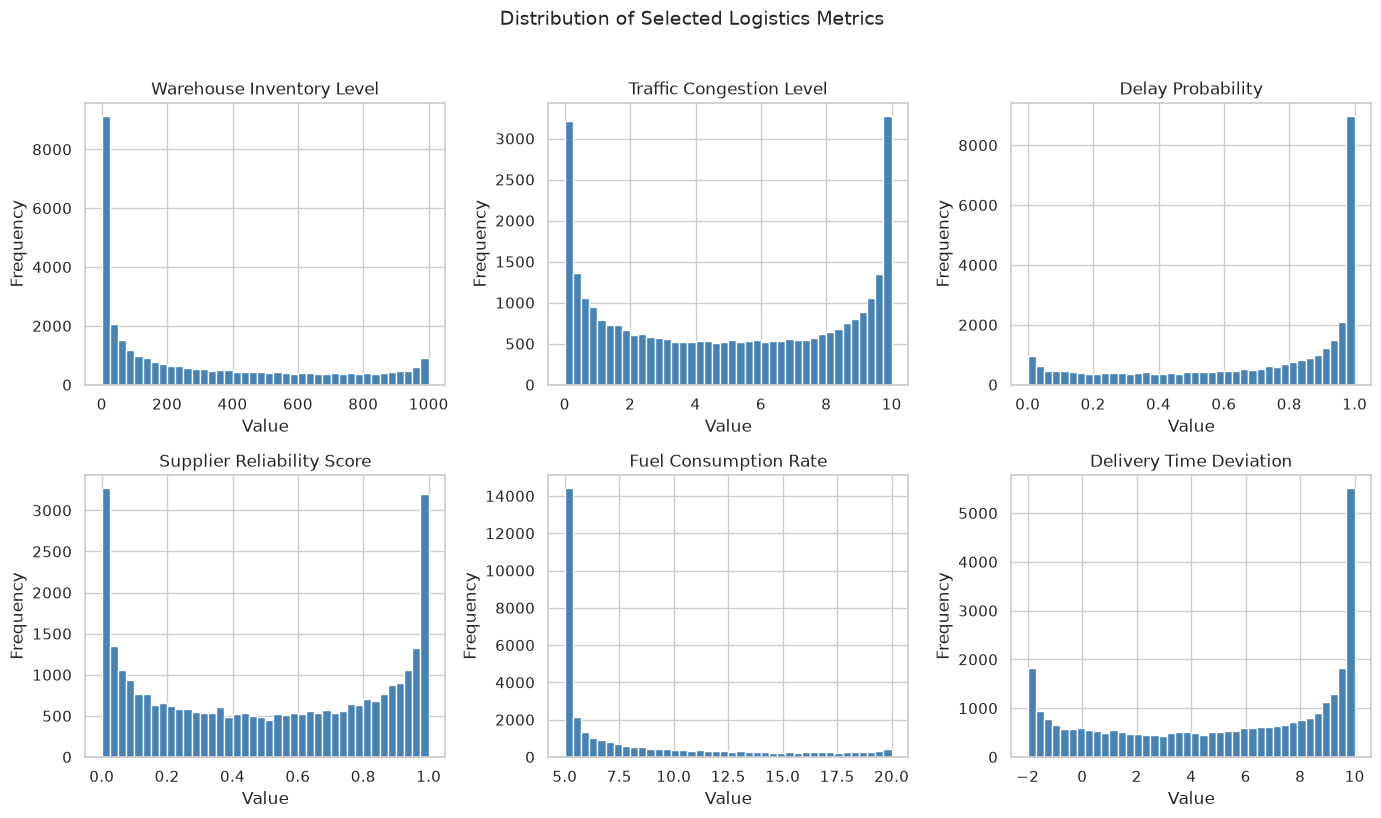

In [10]:
# Step 3c — Distribution histograms
sample_cols = [
    'warehouse_inventory_level',
    'traffic_congestion_level',
    'delay_probability',
    'supplier_reliability_score',
    'fuel_consumption_rate',
    'delivery_time_deviation',
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, sample_cols):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Selected Logistics Metrics', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Step 3c 후:** 어떤 feature가 **균등** vs **skewed**인지 기록하세요. `delivery_time_deviation`처럼 skewed 타깃은 회귀 모델에서 log 변환이나 robust loss가 필요할 수 있습니다.


---

# Part 4 — 시간 패턴

물류 성과는 **시간대**(러시아워), **요일**(주말 휴무), **계절**(날씨, 휴일)에 따라 달라지는 경우가 많습니다.
`timestamp`에서 달력 feature를 파생해 이러한 패턴을 드러냅니다.


### Step 4a — 달력 feature 추가

**이 셀이 하는 일:** 세 개의 새 열을 만듭니다:

| New column | 계산 방법 | 예시 용도 |
|------------|-------------------|-------------|
| `hour` | `timestamp.dt.hour` | 피크 시간대 혼잡 분석 |
| `day_of_week` | `timestamp.dt.day_name()` | 주말 vs 평일 이행 |
| `month` | `to_period('M')` 문자열 | 월별 추세 차트 |

**예상 출력:** 원본 timestamp와 파생 필드가 포함된 5행 미리보기.

> **참고:** 이 feature들은 **엔지니어링**된 것 — 원본 CSV에는 없지만 시계열 EDA에서 표준입니다.


In [11]:
# Step 4a — Calendar features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.to_period('M').astype(str)

df[['timestamp', 'hour', 'day_of_week', 'month']].head()


,timestamp,hour,day_of_week,month
0,2021-01-01 00:00:00,0,Friday,2021-01
1,2021-01-01 01:00:00,1,Friday,2021-01
2,2021-01-01 02:00:00,2,Friday,2021-01
3,2021-01-01 03:00:00,3,Friday,2021-01
4,2021-01-01 04:00:00,4,Friday,2021-01


**Step 4a 후:** DataFrame은 이제 29개 열(원본 26 + 파생 3)입니다.
이후 groupby 연산은 timestamp를 다시 파싱하지 않고 `hour`와 `month`를 사용합니다.


### Step 4b — 시간대별 평균 지연 확률

**이 셀이 하는 일:**

1. 모든 행을 `hour`(0–23)로 그룹화합니다.
2. 시간대별 **평균** `delay_probability`를 계산합니다.
3. 마커가 있는 선 그래프를 그립니다.

**비즈니스 질문:** *특정 시간대가 체계적으로 지연 위험이 더 높은가?*

**차트 읽는 방법:**

- **업무 시간대 상승 기울기** → 혼잡 기반 지연 위험.
- **평평한 선** → 이 합성 데이터셋에서는 지연 위험이 비시간 요인에 의해 좌우될 수 있음.
- 피크를 창고 교대 변경 및 항만 운영 시간과 비교하세요.

**예상 출력:** x축 0–23, y축 평균 delay probability인 선 그래프.


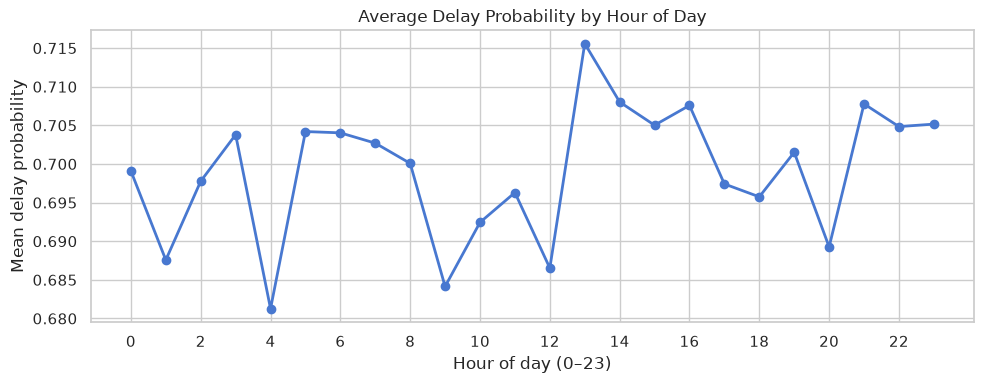

In [12]:
# Step 4b — Delay probability by hour
hourly_delay = df.groupby('hour')['delay_probability'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(hourly_delay['hour'], hourly_delay['delay_probability'], marker='o', linewidth=2)
plt.xlabel('Hour of day (0–23)')
plt.ylabel('Mean delay probability')
plt.title('Average Delay Probability by Hour of Day')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


**해석 프롬프트:** **가장 높은** 평균 delay probability 시간대를 찾으세요.
그 시간에 운전자를 더 배치하면 지연이 줄어들까요, 아니면 원인이 외부적(날씨, 항만)인가요?


### Step 4c — 배송 시간 편차의 월별 추세

**이 셀이 하는 일:** `month`별로 `delivery_time_deviation`을 집계하고 시계열 선 그래프를 그립니다.

**월별 집계를 하는 이유:**

- 시간별 데이터는 노이즈가 많음 — 월별 평균은 **느린 drift**(정책 변경, 유가)를 드러냅니다.
- 리더십이 단시간 스파이크가 아닌 다년 성과를 볼 수 있게 합니다.

**차트 읽는 방법:**

- **상승 추세** → 시간이 지나며 체계적 일정 지연 악화.
- **계절적 파동** → 반복되는 연간 패턴(날씨, 휴일).
- **급격한 점프** → 데이터 생성 변경 또는 실제 중단 조사.

**예상 출력:** 2021-01부터 2024-08까지 ~44개 월별 점이 있는 선 그래프.


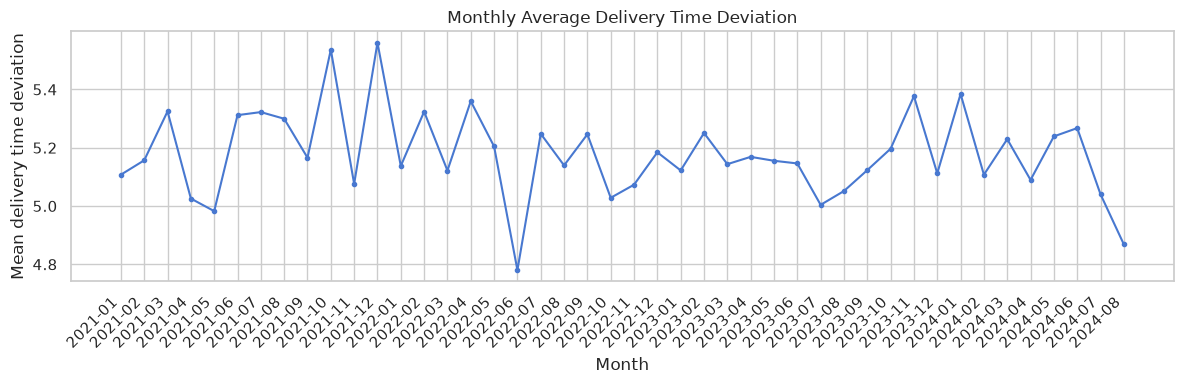

In [13]:
# Step 4c — Monthly delivery deviation trend
monthly_dev = df.groupby('month')['delivery_time_deviation'].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(monthly_dev['month'], monthly_dev['delivery_time_deviation'], marker='.', linewidth=1.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Mean delivery time deviation')
plt.title('Monthly Average Delivery Time Deviation')
plt.tight_layout()
plt.show()


**Part 4 후:** 지연 위험이 **시간대**에 따라 달라지는지, 배송 편차가 **월별**로 drift하는지 설명할 수 있습니다.
다음에는 차량이 **어디서** 운행하는지와 **연료**가 교통과 어떻게 연관되는지 지도로 봅니다.


---

# Part 5 — 위치 및 차량 성능

차량 텔레매틱스는 **GPS 위치**와 **연료 지표**를 결합합니다. 이 파트에서는 지리적 분포와
도로 조건과 연료 소비의 관계를 시각화합니다.


### Step 5a — 북미 지도 위 GPS scatter plot(샘플)

**이 셀이 하는 일:**

1. **3,000행**을 무작위 샘플링합니다(`random_state=42`로 재현 가능).
2. 전체 데이터셋에서 GPS 경계 상자를 계산하고 **북미로 지도를 확대**합니다.
3. `cartopy`로 지역 지도 배경(육지, 해양, 해안선, 미국 주 경계)을 그립니다.
4. `vehicle_gps_longitude`(x)와 `vehicle_gps_latitude`(y)로 차량 위치를 겹칩니다.
5. 각 점을 `fuel_consumption_rate`로 색칠합니다(노랑–주황–빨강 = 높음).

**세계 지도 대신 확대하는 이유:** 이 CSV의 모든 GPS 점은 북미에 있습니다. 잘라내기로
빈 대양과 대륙을 제거해 화물 회랑을 더 쉽게 볼 수 있습니다.

**주요 지리공간 개념:**

| Concept | 이 노트북에서 |
|---------|------------------|
| `PlateCarree()` | 표준 lon/lat 투영(x = 경도, y = 위도) |
| `transform=ccrs.PlateCarree()` | scatter 좌표가 원시 GPS 도임을 cartopy에 알림 |
| `set_extent([west, east, south, north], ...)` | GPS 커버리지 영역으로 지도 자르기 |

**샘플링 이유:** 32,000점은 겹치고 렌더링이 느립니다. 샘플링으로 공간 패턴을 유지합니다.

**지도 읽는 방법:**

- 점은 **육지 또는 해안 근처**에 있어야 함 — 대양 한가운데가 아님(sanity check).
- **클러스터 띠** → 미국·남부 캐나다 공통 화물 회랑.
- **빨간 핫스팟** → 연료 소모가 높은 위치(언덕, 도심 공회전, 우회).

**예상 출력:** GPS 커버리지에 맞게임 북미 지도, colorbar 라벨 *Fuel consumption rate*.


지도 범위 (서, 동, 남, 북): [-122.0, -68.0, 28.0, 52.0]


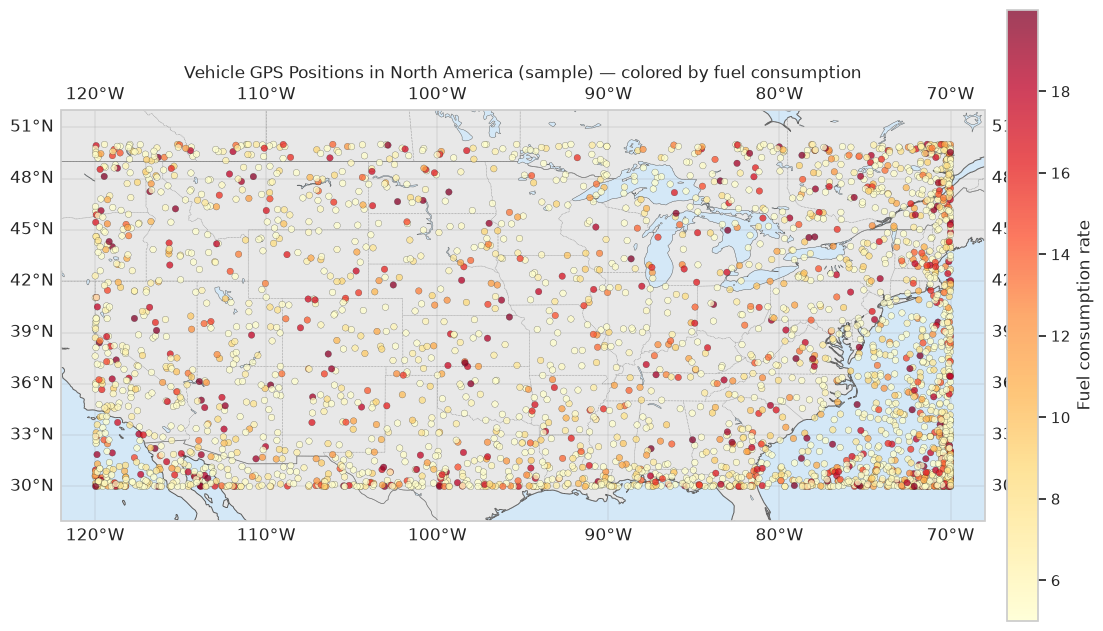

In [14]:
# Step 5a — GPS scatter on North America map colored by fuel consumption
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sample = df.sample(n=3000, random_state=42)

# Crop map to where GPS points actually appear (North America) + small margin
lon_pad, lat_pad = 2.0, 2.0
na_extent = [
    df['vehicle_gps_longitude'].min() - lon_pad,
    df['vehicle_gps_longitude'].max() + lon_pad,
    df['vehicle_gps_latitude'].min() - lat_pad,
    df['vehicle_gps_latitude'].max() + lat_pad,
]
print(f'지도 범위 (서, 동, 남, 북): {[round(v, 2) for v in na_extent]}')

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(na_extent, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#d4e8f7', zorder=0)
ax.add_feature(cfeature.LAND, facecolor='#e8e8e8', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='#555555', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5, edgecolor='#666666', zorder=1)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.4, edgecolor='#999999', zorder=1)
ax.add_feature(cfeature.LAKES, facecolor='#d4e8f7', edgecolor='#555555', linewidth=0.3, zorder=1)

gl = ax.gridlines(
    draw_labels=True,
    dms=False,
    x_inline=False,
    y_inline=False,
    linewidth=0.3,
    color='gray',
    alpha=0.5,
)

sc = ax.scatter(
    sample['vehicle_gps_longitude'],
    sample['vehicle_gps_latitude'],
    c=sample['fuel_consumption_rate'],
    cmap='YlOrRd',
    alpha=0.75,
    s=22,
    edgecolors='k',
    linewidths=0.2,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

cb = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Fuel consumption rate')
ax.set_title('Vehicle GPS Positions in North America (sample) — colored by fuel consumption')

plt.tight_layout()
plt.show()


**Step 5a 후:** 출력된 `na_extent`는 자르기에 사용된 경도/위도 창을 보여줍니다.
해당 박스로 확대하면 빈 지도 영역이 제거되어 미국·캐나다 **화물 회랑**을 더 쉽게 읽을 수 있습니다.

**확장 아이디어(코드 없음):** GPS를 **지역** 또는 **h3 hexagon**으로 binning하고 지역별 평균 delay probability를 비교 — 경로 모델의 흔한 지리공간 feature입니다.


### Step 5b — 연료 소비 vs 교통 혼잡(향상된 joint plot)

**이 셀이 하는 일:** 세 시각 레이어가 있는 **joint plot**을 만듭니다:

| Layer | Chart element | 알려주는 것 |
|-------|---------------|-------------------|
| **Center** | Hexbin heatmap (`YlOrRd`) | (traffic, fuel) 쌍이 주로 모이는 곳 — 밝을수록 행 많음 |
| **Center** | 점선 navy 추세선 | 관계의 전반적 방향(회귀) |
| **Top** | Traffic histogram + KDE | 혼잡 수준 분포 |
| **Right** | Fuel histogram + KDE | 연료 소비 분포 |

**가설:** `traffic_congestion_level`이 높을수록 → 공회전·stop-and-go 증가 → 연료 소모 증가.

**이 차트 읽는 방법:**

1. **주변(marginal)** 플롯부터 — 각 변수 단독 이해.
2. **hexbin** 중심 — 가장 밝은 셀(밀도 최대)을 따름.
3. **추세선** 확인 — 상승 기울기는 traffic → fuel 가설을 지지.

**예상 출력:** colorbar *Number of observations*가 있는 큰 joint figure.


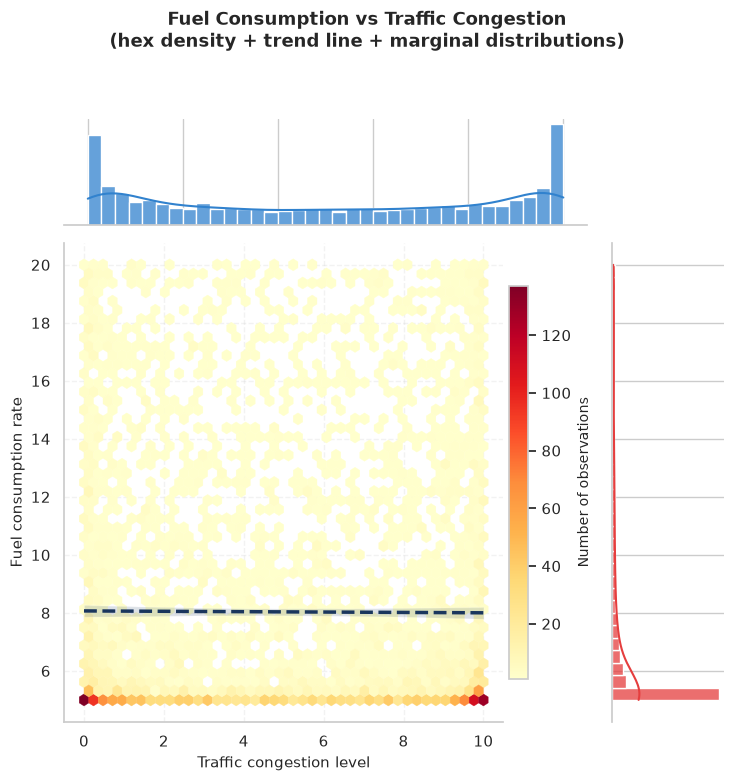

In [15]:
# Step 5b — Fuel vs traffic (hexbin joint plot + trend + marginals)
fuel_traffic = df.sample(n=5000, random_state=42)

g = sns.JointGrid(
    data=fuel_traffic,
    x='traffic_congestion_level',
    y='fuel_consumption_rate',
    height=7.5,
    ratio=4,
    space=0.08,
)

hexbin = g.ax_joint.hexbin(
    fuel_traffic['traffic_congestion_level'],
    fuel_traffic['fuel_consumption_rate'],
    gridsize=42,
    cmap='YlOrRd',
    mincnt=1,
    linewidths=0.25,
    edgecolors='face',
)
cbar = g.fig.colorbar(hexbin, ax=g.ax_joint, shrink=0.82, pad=0.01)
cbar.set_label('Number of observations', fontsize=10)

sns.regplot(
    data=fuel_traffic,
    x='traffic_congestion_level',
    y='fuel_consumption_rate',
    ax=g.ax_joint,
    scatter=False,
    color='#1a365d',
    line_kws={'linewidth': 2.5, 'linestyle': '--'},
)

sns.histplot(
    data=fuel_traffic,
    x='traffic_congestion_level',
    ax=g.ax_marg_x,
    kde=True,
    color='#3182ce',
    alpha=0.75,
    edgecolor='white',
    bins=35,
)
sns.histplot(
    data=fuel_traffic,
    y='fuel_consumption_rate',
    ax=g.ax_marg_y,
    kde=True,
    color='#e53e3e',
    alpha=0.75,
    edgecolor='white',
    bins=35,
)

g.ax_joint.set_xlabel('Traffic congestion level', fontsize=11)
g.ax_joint.set_ylabel('Fuel consumption rate', fontsize=11)
g.ax_joint.grid(True, alpha=0.25, linestyle='--')
g.fig.suptitle(
    'Fuel Consumption vs Traffic Congestion\n'
    '(hex density + trend line + marginal distributions)',
    y=1.04,
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()


**Step 5b 해석 방법:**

- 중앙의 **밝은 hex 셀**은 가장 흔한 운영 조건을 표시합니다.
- **점선**이 위로 기울면 혼잡과 연료 사용이 함께 증가하는 경향이 있습니다.
- **주변 KDE 곡선**(상단/우측의 매끈한 선)은 값이 낮·중·높은 수준에 몰리는지 보여줍니다.

**Part 5 후:** 연료와 교통은 **예측 정비** 및 **그린 물류** 이니셔티브의 입력입니다.
Part 6에서는 **배송 지연**을 직접 살펴봅니다.


---

# Part 6 — 교통, ETA 및 지연

이 파트는 **정시 배송 성과**에 초점을 맞춥니다: 교통과 ETA 업데이트가 delay probability 및
실제 배송 편차와 어떻게 연관되는지. 이 열들은 경로 최적화 사용 사례의 핵심입니다.

> **공유 샘플:** Step 6b가 `plot_sample`(4,000행)을 만들어 Part 6–13 scatter plot에 일관되게 재사용합니다.


### Step 6a — 교통 혼잡 분포

**이 셀이 하는 일:** 32,065행 전체에 대한 `traffic_congestion_level` 히스토그램.

**단변량 뷰부터 시작하는 이유:** 교통을 결과와 상관시키기 전에 혼잡이 보통 낮은지, 높은지, 균등 분포인지 이해합니다.

**예상 출력:** x축 = 혼잡 지수, y축 = 빈도인 단일 히스토그램.


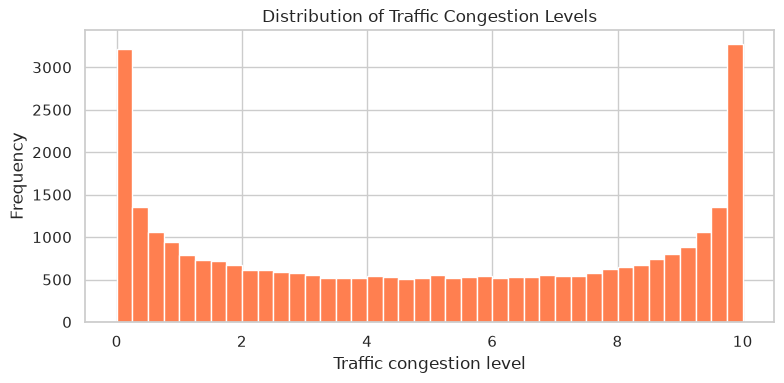

In [16]:
# Step 6a — Traffic congestion histogram
plt.figure(figsize=(8, 4))
plt.hist(df['traffic_congestion_level'], bins=40, color='coral', edgecolor='white')
plt.xlabel('Traffic congestion level')
plt.ylabel('Frequency')
plt.title('Distribution of Traffic Congestion Levels')
plt.tight_layout()
plt.show()


**Step 6a 후:** 분포가 대략 균등하면 혼잡이 실제 traffic API가 아닌 합성 샘플일 수 있습니다 — 관계 교육에는 여전히 유효합니다.


### Step 6b — 교통 혼잡 vs 배송 시간 편차

**이 셀이 하는 일:**

1. `plot_sample = df.sample(4000, random_state=7)` — 가벼운 scatter plot용.
2. `sns.regplot` — scatter 점 **+** 선형 회귀 추세선.

**사용 열:**

| Axis | Column | 의미 |
|------|--------|---------|
| x | `traffic_congestion_level` | 도로 혼잡 지수 |
| y | `delivery_time_deviation` | 일정 지연 크기 |

**regplot 읽는 방법:**

- **위로 기울어진 빨간 선** → 혼잡이 클수록 편차도 큰 경향.
- **평평한 선** → 선형 연관 약함(비선형 모델은 여전히 도움될 수 있음).
- **넓은 scatter** → 개별 배송은 다른 요인이 지배.

**예상 출력:** 반투명 점과 진한 빨간 추세선이 있는 scatter.


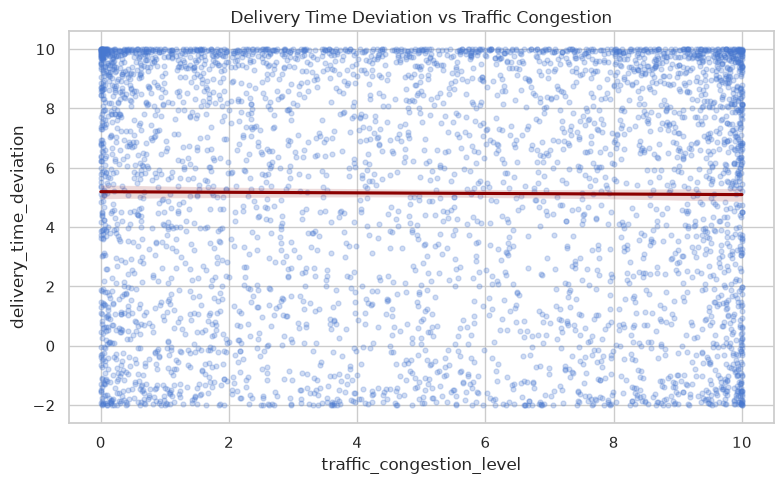

In [17]:
# Step 6b — Traffic vs delivery deviation
plot_sample = df.sample(n=4000, random_state=7)

plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='traffic_congestion_level',
    y='delivery_time_deviation',
    scatter_kws={'alpha': 0.25, 's': 12},
    line_kws={'color': 'darkred'},
)
plt.title('Delivery Time Deviation vs Traffic Congestion')
plt.tight_layout()
plt.show()


**비즈니스 시사점:** 혼잡이 편차와 상관되면 dispatch 시 고교통 edge에 penalty를 주는 경로 최적화가 필요합니다 — VRP(vehicle routing problem)의 핵심 제약입니다.


### Step 6c — ETA 변화 vs 지연 확률

**이 셀이 하는 일:** `eta_variation_hours`(x) vs `delay_probability`(y) scatter plot.

**필드 상기:**

- `eta_variation_hours` — 양수는 계획 대비 ETA가 **늦게** 수정됨을 의미.
- `delay_probability` — 약속 배송 창을 놓칠 모델 추정 확률.

**시각적으로 답할 질문:** planner가 이미 ETA를 위로 수정한 경우 delay probability도 높은가?

**예상 출력:** 점 구름; 밀집 영역에서 상승 추세를 찾으세요.


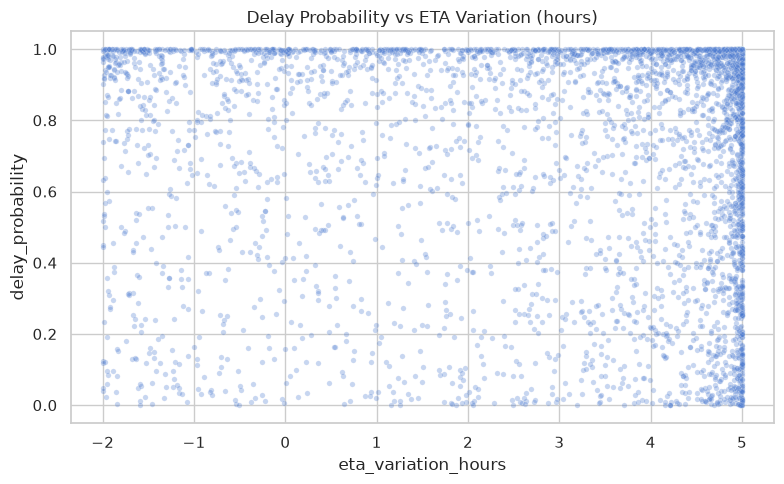

In [18]:
# Step 6c — ETA variation vs delay probability
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='eta_variation_hours',
    y='delay_probability',
    alpha=0.3,
    s=15,
)
plt.title('Delay Probability vs ETA Variation (hours)')
plt.tight_layout()
plt.show()


**Part 6 후:** **traffic → delay** 스토리를 세 각도에서 탐색했습니다: 분포, 배송 편차, ETA 업데이트.
Part 7에서는 **창고 및 이행** 신호로 전환합니다.


---

# Part 7 — 창고 및 이행(fulfillment)

창고 운영은 **재고**, **수요**, **도크 효율**, **주문 이행**을 연결합니다.
상류 재고 배치나 장비 부족은 하류에서 배송 위험으로 나타나는 경우가 많습니다.


### Step 7a — 재고 수준 vs 과거 수요

**이 셀이 하는 일:** 다음 aesthetic이 있는 scatter plot:

| Aesthetic | Column | 역할 |
|-----------|--------|------|
| x-axis | `historical_demand` | 과거 고객 수요 |
| y-axis | `warehouse_inventory_level` | 현재 보유 재고 |
| color | `order_fulfillment_status` | 이행 성공(viridis: 노랑→초록) |

**클러스터 해석:**

- 대각선 아래(수요 대비 재고 낮음) → stockout 위험.
- 재고 낮은 **초록** 점 → 긴급 이행 또는 backorder 가능.
- 재고 높은 **보라** 점 → 과잉 재고 또는 slow mover.

**예상 출력:** 색상 scatter — *Warehouse Inventory vs Historical Demand*.


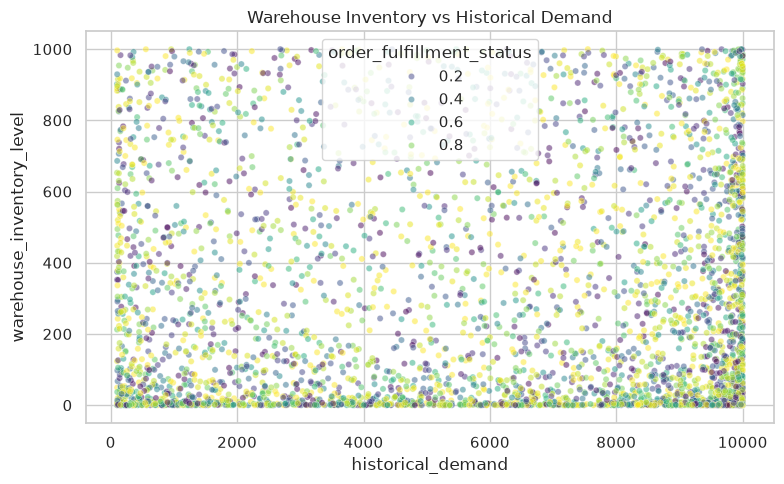

In [19]:
# Step 7a — Inventory vs demand scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='historical_demand',
    y='warehouse_inventory_level',
    hue='order_fulfillment_status',
    palette='viridis',
    alpha=0.5,
    s=20,
)
plt.title('Warehouse Inventory vs Historical Demand')
plt.tight_layout()
plt.show()


**Module 8 연결:** `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb`로 계속하여
창고, 수요, 위험을 **Neo4j 지식 그래프**로 모델링하세요.


### Step 7b — 장비 가용성 vs 적하/하역 시간

**이 셀이 하는 일:** `handling_equipment_availability`(x) vs `loading_unloading_time`(y) `sns.regplot`.

**운영 스토리:** 지게차와 도크는 **용량 제약**입니다. 가용성이 떨어지면
트레일러 대기 시간이 늘어 `loading_unloading_time`이 증가하고 ETA miss로 연쇄됩니다.

**예상 추세:** 음의 기울기 — 장비 적음 → 도크 시간 증가.

**예상 출력:** Scatter + 회귀선.


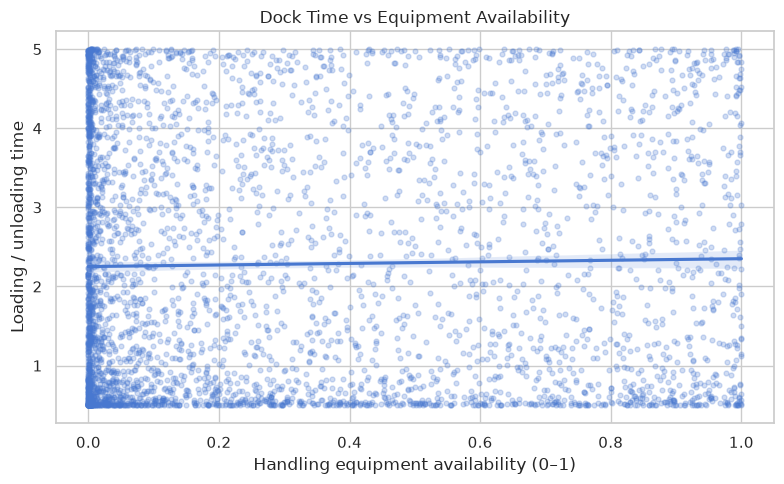

In [20]:
# Step 7b — Equipment availability vs dock time
plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='handling_equipment_availability',
    y='loading_unloading_time',
    scatter_kws={'alpha': 0.25, 's': 12},
)
plt.xlabel('Handling equipment availability (0–1)')
plt.ylabel('Loading / unloading time')
plt.title('Dock Time vs Equipment Availability')
plt.tight_layout()
plt.show()


**실행 가능한 인사이트:** handling equipment 정비 일정은 **통제 가능한 레버**입니다 —
날씨나 항만 파업과 달리.


### Step 7c — 위험 등급별 주문 이행 상태

**이 셀이 하는 일:**

1. `risk_classification`으로 그룹화.
2. 등급별 평균 `order_fulfillment_status` 계산.
3. 수평 막대 그래프(초록/주황/빨강).
4. 차트 아래 숫자 테이블 출력.

**질문:** High Risk 시간대에 평균 이행도 낮은가?

**예상 출력:** 막대 그래프 + 작은 Series 테이블.


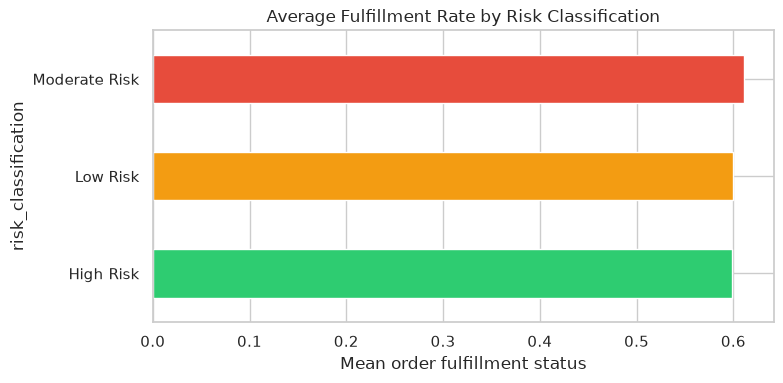

risk_classification
High Risk       0.599
Low Risk        0.599
Moderate Risk   0.611
Name: order_fulfillment_status, dtype: float64

In [21]:
# Step 7c — Fulfillment by risk classification
fulfillment_by_risk = df.groupby('risk_classification')['order_fulfillment_status'].mean().sort_values()

plt.figure(figsize=(8, 4))
fulfillment_by_risk.plot(kind='barh', color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.xlabel('Mean order fulfillment status')
plt.title('Average Fulfillment Rate by Risk Classification')
plt.tight_layout()
plt.show()
fulfillment_by_risk


**Part 7 후:** 창고 지표는 고객 대면 지연 위험의 **상류** 원인을 설명합니다.
Part 8에서는 **외부** 요인: 날씨와 항만을 살펴봅니다.


---

# Part 8 — 날씨 및 항만 혼잡

복합 수송 공급망은 **트럭**, **항만**, **철도** 간 화물을 넘깁니다. 날씨와
터미널 적체는 전형적인 **외생(exogenous)** 변수 — 통제는 어렵지만 예측은 필수입니다.


### Step 8a — 나란히 분포

**이 셀이 하는 일:** 한 행에 두 히스토그램:

| Subplot | Column | Color |
|---------|--------|-------|
| Left | `weather_condition_severity` | Sky blue |
| Right | `port_congestion_level` | Slate blue |

**분포를 함께 보는 이유:** 둘 다 외부 스트ress 지수 — 형태를 나란히 보면
지연과 상관시키기 전에 스케일이 비슷한지 판단하기 쉽습니다.

**예상 출력:** 두 히스토그램이 있는 1×2 figure.


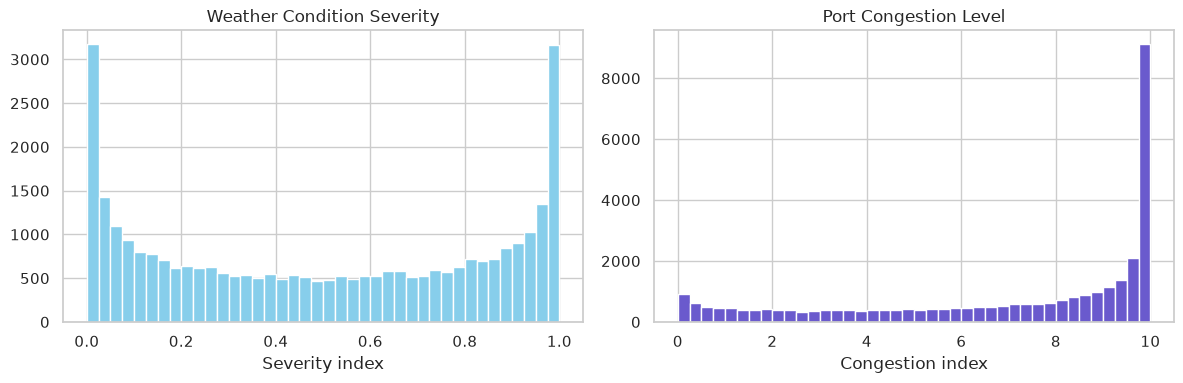

In [22]:
# Step 8a — Weather and port congestion distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['weather_condition_severity'], bins=40, color='skyblue', edgecolor='white')
axes[0].set_title('Weather Condition Severity')
axes[0].set_xlabel('Severity index')

axes[1].hist(df['port_congestion_level'], bins=40, color='slateblue', edgecolor='white')
axes[1].set_title('Port Congestion Level')
axes[1].set_xlabel('Congestion index')

plt.tight_layout()
plt.show()


**성찰:** 어떤 지수가 더 극단적 꼬리 이벤트를 보이는가? 꼬리 위험은 보험 및
비상 경로 정책을 자주 좌우합니다.


### Step 8b — 날씨 심각도 vs 배송 시간 편차

**이 셀이 하는 일:**

1. `pd.cut(..., bins=5)` — 날씨 심각도를 **5개 등간 bin**으로 분할.
2. bin별 평균 `delivery_time_deviation` 계산.
3. 막대 그래프.

**scatter 대신 binning하는 이유:** 날씨 영향은 종종 **비선형** — 폭풍은 가벼운 비보다 훨씬 중요합니다. Binning으로 초급 학습자도 보기 쉬운 단계 변화를 드러냅니다.

**막대 읽기:** 왼→오 막대 높이 증가 → 악화 날씨와 더 큰 편차 정렬.

**예상 출력:** x축 5개 날씨 bin 막대 그래프.


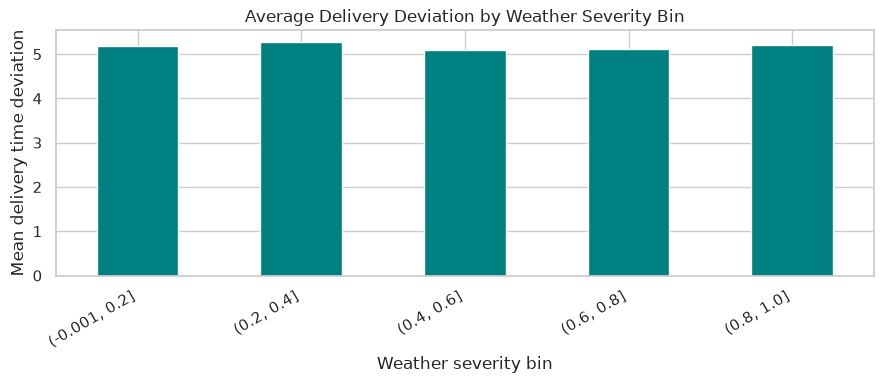

In [23]:
# Step 8b — Weather impact on delivery deviation
weather_bins = pd.cut(df['weather_condition_severity'], bins=5)
weather_impact = df.groupby(weather_bins, observed=True)['delivery_time_deviation'].mean()

plt.figure(figsize=(9, 4))
weather_impact.plot(kind='bar', color='teal', edgecolor='white')
plt.xlabel('Weather severity bin')
plt.ylabel('Mean delivery time deviation')
plt.title('Average Delivery Deviation by Weather Severity Bin')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**추가 읽기(코드 없음):** 프로덕션에서는 [NOAA weather feeds](https://www.ncei.noaa.gov/)와 조인해
합성 severity를 실측 강수·풍속으로 대체하세요.


---

# Part 9 — 공급업체, lead time 및 운송 비용

상류 공급업체 성과는 창고가 제때 재고를 받는지에 영향을 줍니다. 이 파트에서는
**신뢰성 점수**, **lead time**, **운송 경제**를 탐색합니다.


### Step 9a — 공급업체 신뢰성 분포

**이 셀이 하는 일:** `supplier_reliability_score` 히스토그램(0 = 신뢰 낮음, 1 = 매우 신뢰).

**조달 맥락:** 조직은 이런 점수로 공급업체 tier(A/B/C)를 나누어
발주 할당 및 safety stock 규칙에 사용하는 경우가 많습니다.

**예상 출력:** 0–1 사이 어딘가를 중심으로 한 분포 — 낮거나 높은 신뢰 쪽 skew에 주목.


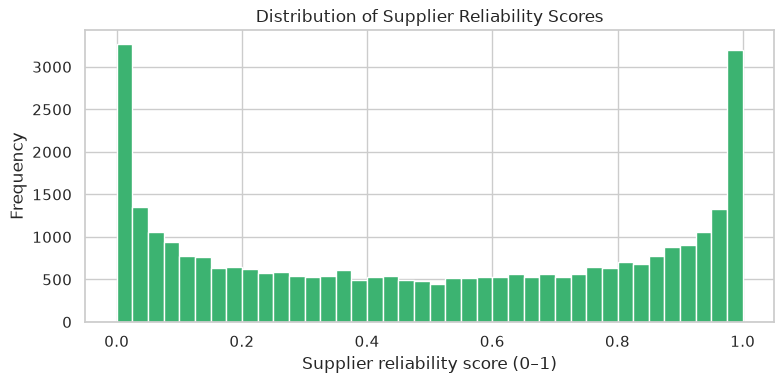

In [24]:
# Step 9a — Supplier reliability histogram
plt.figure(figsize=(8, 4))
plt.hist(df['supplier_reliability_score'], bins=40, color='mediumseagreen', edgecolor='white')
plt.xlabel('Supplier reliability score (0–1)')
plt.ylabel('Frequency')
plt.title('Distribution of Supplier Reliability Scores')
plt.tight_layout()
plt.show()


**질문:** 많은 공급업체가 0.5 신뢰 아래에 몰리면 dual-sourcing 네트워크 설계가 필요할 수 있습니다.


### Step 9b — Lead time vs 운송 비용

**이 셀이 하는 일:** `lead_time_days`(x) vs `shipping_costs`(y) scatter.

**수업에서 논의할 트레이드오프:**

- **항공 운송** — lead time 짧음, 비용 높음.
- **해상 운송** — lead time 김, 단위당 비용 낮음.

이 합성 데이터에서 lead time이 길수록 shipping costs가 낮은지 살펴보세요.

**예상 출력:** `plot_sample`에서 4,000점 scatter.


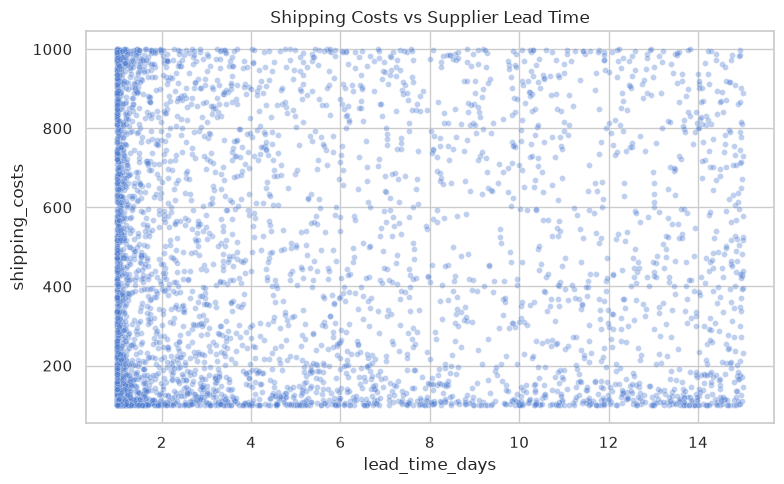

In [25]:
# Step 9b — Lead time vs shipping costs
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='lead_time_days',
    y='shipping_costs',
    alpha=0.35,
    s=18,
)
plt.title('Shipping Costs vs Supplier Lead Time')
plt.tight_layout()
plt.show()


**Step 9b 후:** 조달 대시보드는 종종 **효율적 frontier** — 속도와 비용 간 Pareto-optimal 선택 — 로 그립니다.


### Step 9c — 공급업체 신뢰성 vs 중단 가능성

**이 셀이 하는 일:** `supplier_reliability_score`와 `disruption_likelihood_score`를 연결하는 regression plot.

**가설:** 신뢰 낮은 공급업체는 네트워크 전체 중단 위험 증가(stockout, 긴급 비용, 라인 정지).

**예상 추세:** 음의 기울기 — 신뢰 높음 → 중단 가능성 낮음.

**예상 출력:** scatter와 보라색 추세선.


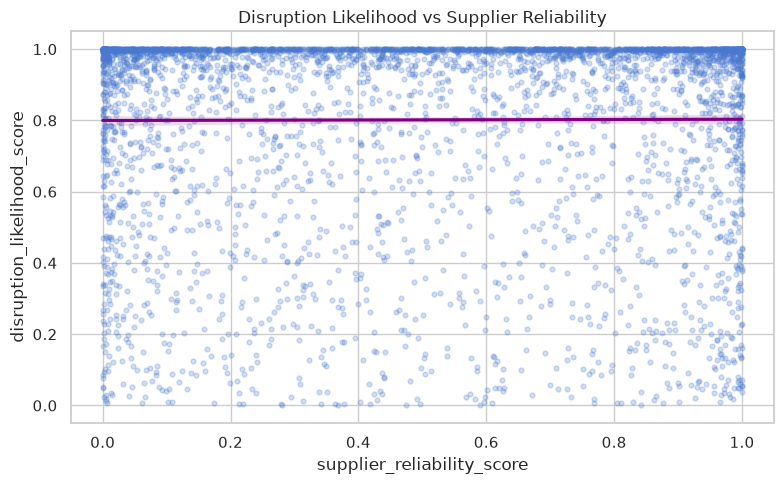

In [26]:
# Step 9c — Reliability vs disruption score
plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='supplier_reliability_score',
    y='disruption_likelihood_score',
    scatter_kws={'alpha': 0.25, 's': 12},
    line_kws={'color': 'purple'},
)
plt.title('Disruption Likelihood vs Supplier Reliability')
plt.tight_layout()
plt.show()


**Part 9 후:** 공급업체 지표는 Part 12에서 다루는 **risk classification** 모델에 공급됩니다.


---

# Part 10 — IoT 온도, 화물 상태 및 경로 위험

콜드체인 및 고가 화물은 **센서 모니터링**과 **경로 위험 평가**가 필요합니다.
통관 지연은 국제 국경에서 마찰을 추가합니다.


### Step 10a — IoT 온도 분포(콜드체인)

**이 셀이 하는 일:** `iot_temperature` 히스토그램, **0°C 빨간 점선** 기준선.

**콜드체인 primer:**

| Temperature zone | Typical goods |
|------------------|---------------|
| Below 0°C | 냉동 식품, 일부 백신 |
| 2–8°C | 냉장 의약품 |
| Ambient | 일반 상품 |

**알림 로직(개념):** 제품군 안전 범위를 크게 벗어나면 QA hold 트리거.

**예상 출력:** 음수~양수 °C 히스토그램.


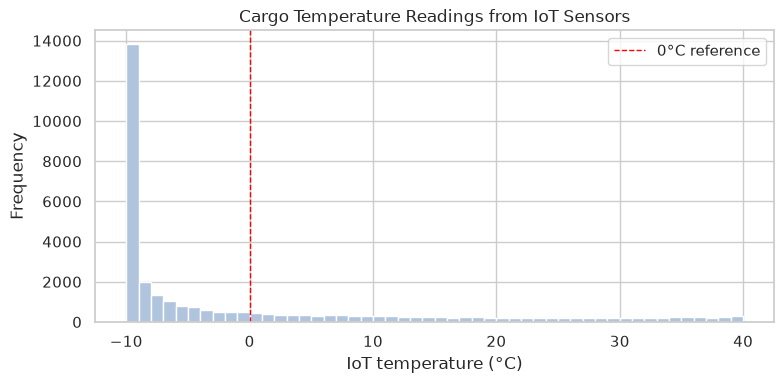

In [27]:
# Step 10a — IoT temperature histogram
plt.figure(figsize=(8, 4))
plt.hist(df['iot_temperature'], bins=50, color='lightsteelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='0°C reference')
plt.xlabel('IoT temperature (°C)')
plt.ylabel('Frequency')
plt.title('Cargo Temperature Readings from IoT Sensors')
plt.legend()
plt.tight_layout()
plt.show()


**안전 참고:** 실제 배포는 SKU별 임계값을 정의 — 모든 SKU에 단일 0°C 선을 쓰지 마세요.


### Step 10b — 화물 상태 vs 경로 위험

**이 셀이 하는 일:** `route_risk_level`(x) vs `cargo_condition_status`(y) scatter.

**Fields:**

- `route_risk_level` — 경로상 지정학, 인프라 또는 보안 위험.
- `cargo_condition_status` — 0–1 무결성 점수(손상, 변조, 온도 이탈 집계).

**질문:** 고위험 경로가 더 나쁜 화물 상태와 상관되는가?

**예상 출력:** Scatter — 위험이 cargo handling 품질을 해치면 하향 추세.


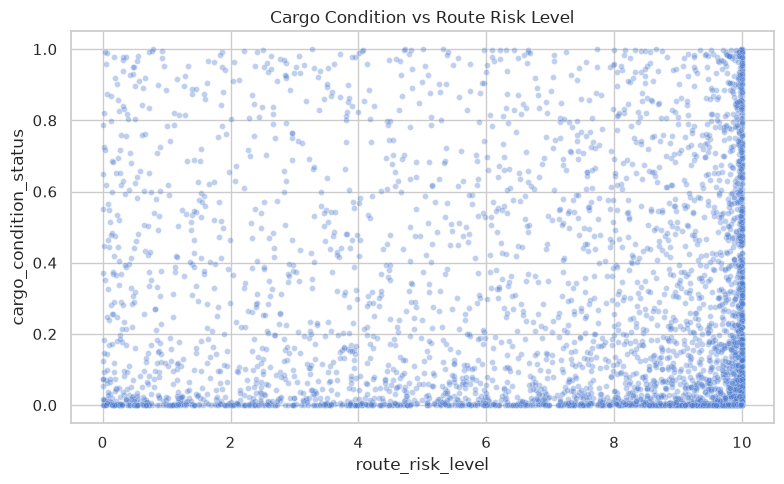

In [28]:
# Step 10b — Cargo condition vs route risk
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='route_risk_level',
    y='cargo_condition_status',
    alpha=0.35,
    s=18,
)
plt.title('Cargo Condition vs Route Risk Level')
plt.tight_layout()
plt.show()


**사용 사례 연결:** 보험사와 감사인은 유사 플롯으로 **화물 보험** 가격 책정 및 lane 승인에 활용합니다.


### Step 10c — 통관 clearance time 분포

**이 셀이 하는 일:** `customs_clearance_time` 히스토그램 — 통관 처리 소요 시간.

**국제 lane에서 중요한 이유:**

- 예기치 않은 통관 hold는 콜드체인 타이머를 깨뜨립니다.
- 서류 오류는 clearance time 꼬리에서 나타납니다.

**예상 출력:** 대부분 빠르고 가끔 긴 지연이 있으면 오른쪽 skew 히스토그램.


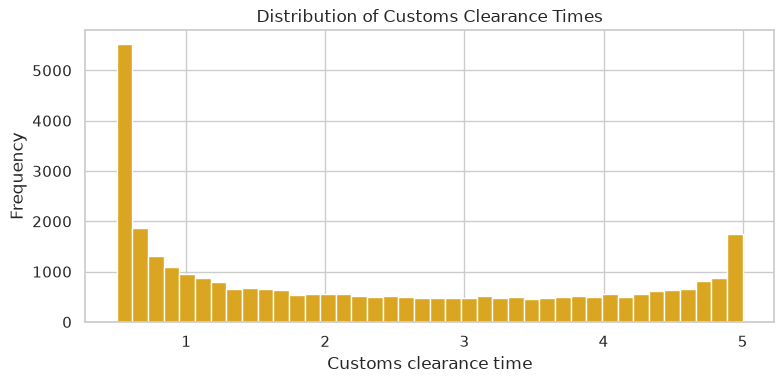

In [29]:
# Step 10c — Customs clearance time
plt.figure(figsize=(8, 4))
plt.hist(df['customs_clearance_time'], bins=40, color='goldenrod', edgecolor='white')
plt.xlabel('Customs clearance time')
plt.ylabel('Frequency')
plt.title('Distribution of Customs Clearance Times')
plt.tight_layout()
plt.show()


**Part 10 후:** IoT 및 통관 feature는 **규제** 공급망(제약, 식품, 방산)에서 가장 중요합니다.


---

# Part 11 — 운전자 행동 및 피로 모니터링

텔레매틱스 플랫폼은 **운전 스타일**(급제동, 과속)과 **피로**(근무 시간, 카메라 기반 졸음)를 점수화합니다.
이 인적 요인 지표는 차량·교통 데이터를 보완합니다.


### Step 11a — 운전자 행동 점수 분포

**이 셀이 하는 일:** 모든 관측치에 대한 `driver_behavior_score` 히스토그램.

**점수 해석(일반 vendor 스케일):**

- **1.0 근처** — 부드럽고 규정 준수 운전.
- **0.0 근처** — 잦은 harsh event; 코칭 또는 보험 할증 트리거 가능.

**예상 출력:** fleet가 각 행동 tier에서 얼마나 자주 운행하는지 보여주는 분포.


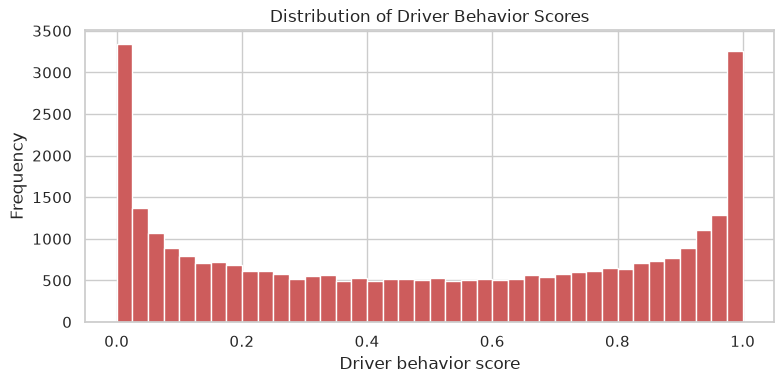

In [30]:
# Step 11a — Driver behavior histogram
plt.figure(figsize=(8, 4))
plt.hist(df['driver_behavior_score'], bins=40, color='indianred', edgecolor='white')
plt.xlabel('Driver behavior score')
plt.ylabel('Frequency')
plt.title('Distribution of Driver Behavior Scores')
plt.tight_layout()
plt.show()


**Fleet safety 프로그램**은 이 분포로 코칭 임계값 설정 — 예: 매월 하위 decile 운전자 flag.


### Step 11b — 피로 점수 vs 지연 확률

**이 셀이 하는 일:** `fatigue_monitoring_score` vs `delay_probability` `sns.regplot`.

**가설:** 피로 운전자는 더 느리게, 휴식을 더 자주, 또는 실수 → 지연 위험 증가.

**주의:** 피로 점수 방향은 vendor마다 다름(일부는 높을수록 더 피로). vendor 문서를 확인하세요.

**예상 출력:** 회귀 추세가 있는 scatter.


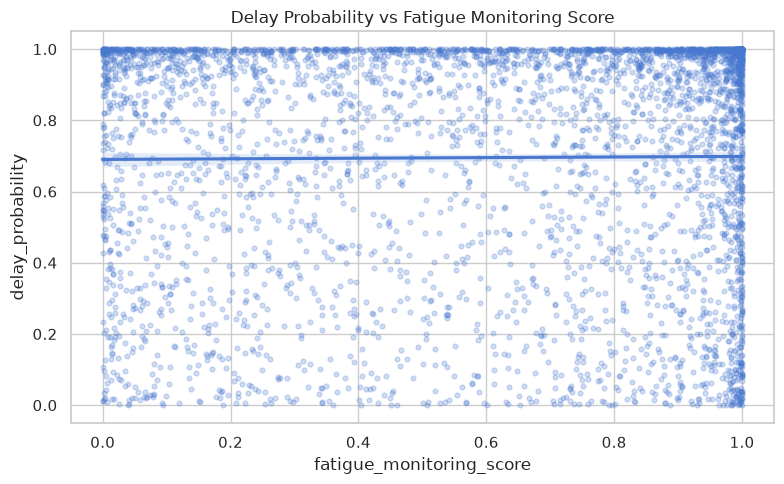

In [31]:
# Step 11b — Fatigue vs delay probability
plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='fatigue_monitoring_score',
    y='delay_probability',
    scatter_kws={'alpha': 0.25, 's': 12},
)
plt.title('Delay Probability vs Fatigue Monitoring Score')
plt.tight_layout()
plt.show()


**정책 연결:** 근무 시간(HOS) 규정은 운송 안전 연구에서 피로-지연 관계가 잘 문서화되어 있기 partly 존재합니다.


---

# Part 12 — 위험 점수 및 분류

이 파트는 ML 프로젝트에서 예측할 **타깃**에 초점: `risk_classification`,
`disruption_likelihood_score`, `delay_probability`. 분류기 학습 전 **클래스 균형** 이해가 필수입니다.


### Step 12a — 위험 분류 개수

**이 셀이 하는 일:**

1. `risk_classification` 범주별 행 개수.
2. 막대 순서: Low → Moderate → High.
3. 막대 그래프 및 개수 출력.

**클래스 불균형 경고:** **High Risk**가 지배하면 accuracy만으로는 misleading — 항상 High Risk를 예측하는 naive 모델도 정확해 보일 수 있음.

**더 나은 지표:** F1-score, precision-recall AUC, confusion matrix.

**예상 출력:** 막대 그래프 + count Series(이 데이터셋에서 ~75% High Risk).


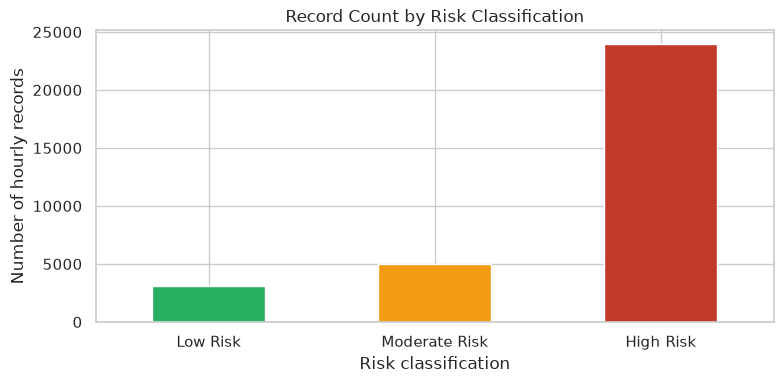

risk_classification
Low Risk          3110
Moderate Risk     5011
High Risk        23944
Name: count, dtype: int64

In [32]:
# Step 12a — Risk classification bar chart
risk_counts = df['risk_classification'].value_counts()
order = ['Low Risk', 'Moderate Risk', 'High Risk']
risk_counts = risk_counts.reindex(order)

plt.figure(figsize=(8, 4))
risk_counts.plot(kind='bar', color=['#27ae60', '#f39c12', '#c0392b'], edgecolor='white')
plt.xlabel('Risk classification')
plt.ylabel('Number of hourly records')
plt.title('Record Count by Risk Classification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
risk_counts


**Teaching moment:** `% High Risk` = count / 32065 계산을 학생에게 요청. stratified train/test split을 논의.


### Step 12b — 위험 등급별 평균 지표(heatmap)

**이 셀이 하는 일:**

1. 위험 관련 숫자 열 6개 선택.
2. `risk_classification`으로 그룹화해 평균 계산.
3. **heatmap** 표시(빨강 = 높음, 초록 = 낮음, 테이블 기준).

**heatmap 읽는 방법:**

- 동일 metric에서 **행**(위험 등급) 비교.
- High Risk 행에 delay, disruption, traffic 등이 높아야 label이 일관됨.

**예상 출력:** 3×6 annotated heatmap + 기본 테이블.


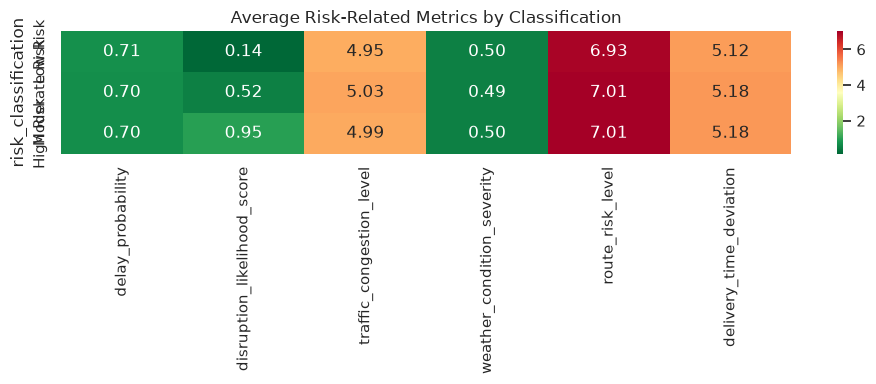

,delay_probability,disruption_likelihood_score,traffic_congestion_level,weather_condition_severity,route_risk_level,delivery_time_deviation
risk_classification,,,,,,
Low Risk,0.707,0.143,4.950,0.503,6.934,5.118
Moderate Risk,0.696,0.519,5.029,0.494,7.005,5.184
High Risk,0.699,0.949,4.989,0.498,7.009,5.184


In [33]:
# Step 12b — Mean metrics by risk class
risk_metrics = [
    'delay_probability',
    'disruption_likelihood_score',
    'traffic_congestion_level',
    'weather_condition_severity',
    'route_risk_level',
    'delivery_time_deviation',
]
risk_summary = df.groupby('risk_classification')[risk_metrics].mean().loc[order]

plt.figure(figsize=(10, 4))
sns.heatmap(risk_summary, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title('Average Risk-Related Metrics by Classification')
plt.tight_layout()
plt.show()
risk_summary


**검증:** Low Risk 행의 평균 `delay_probability`가 High Risk보다 *높으면* label 품질 또는
feature scaling을 지도 학습 전에 조사하세요.


### Step 12c — 중단 가능성 vs 지연 확률

**이 셀이 하는 일:** `risk_classification`으로 색칠한 scatter — 두 복합 점수와 범주 label을 시각 검증.

**Color key:**

| Color | Class |
|-------|-------|
| Green | Low Risk |
| Orange | Moderate Risk |
| Red | High Risk |

**예상 패턴:** disruption·delay 점수가 모두 높은 곳에 빨간 점 cluster.

**예상 출력:** 다색 scatter plot.


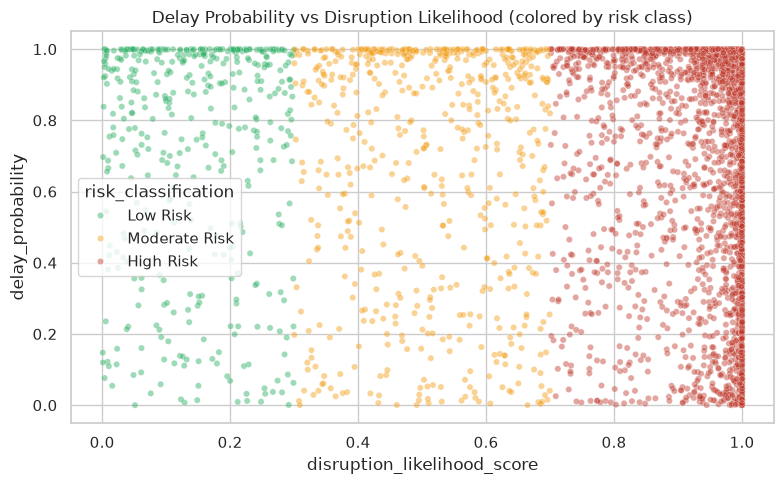

In [34]:
# Step 12c — Disruption vs delay scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='disruption_likelihood_score',
    y='delay_probability',
    hue='risk_classification',
    hue_order=order,
    palette={'Low Risk': '#27ae60', 'Moderate Risk': '#f39c12', 'High Risk': '#c0392b'},
    alpha=0.45,
    s=20,
)
plt.title('Delay Probability vs Disruption Likelihood (colored by risk class)')
plt.tight_layout()
plt.show()


**Part 12 후:** label 불균형과 feature space에서의 위험 등급 분리를 이해했습니다.
Part 13에서는 **모든 쌍wise 상관관계**로 확대합니다.


---

# Part 13 — 상관관계 개요

ML feature 선택 전 분석가는 **상관관계 행렬**로 중복(같은 것을 측정하는 두 열)과
결과의 강한 predictor를 찾는 경우가 많습니다.

> **주의:** 상관관계는 **선형** 연관만 측정합니다. 비선형 관계는 놓칠 수 있습니다.
> 상관관계 **≠** 인과관계.


### Step 13a — 상관관계 heatmap(숫자 열)

**이 셀이 하는 일:**

1. 모든 numeric dtype 선택(파생 `hour` 포함 가능).
2. Pearson 상관 행렬 계산.
3. coolwarm colormap 전체 heatmap(파랑 = 음, 빨강 = 양).

**큰 heatmap 스캔 방법:**

- 대각선 밖 **밝은 빨강/파랑** 사각형 찾기.
- `delivery_time_deviation` 열/행과의 상관 확인.
- |r| > 0.7 쌍은 redundant feature 후보.

**예상 출력:** 큰 16×12 figure — Jupyter에서 확대하거나 스크롤.


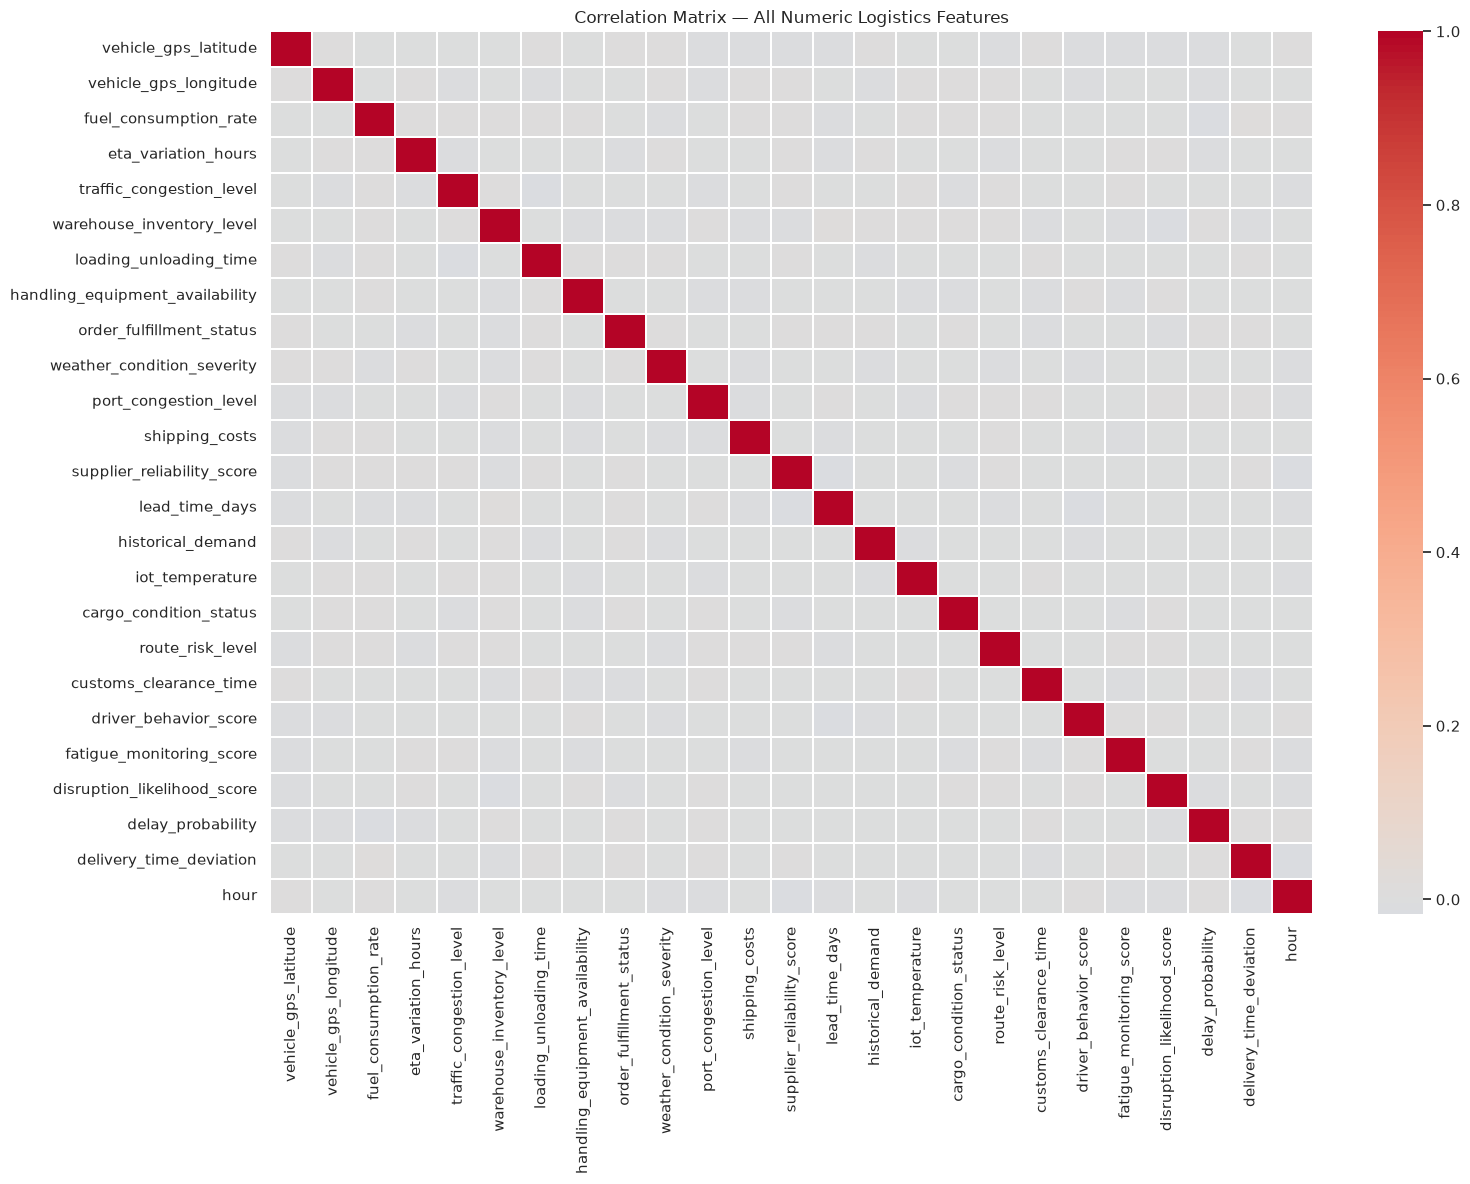

In [35]:
# Step 13a — Correlation heatmap
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Matrix — All Numeric Logistics Features')
plt.tight_layout()
plt.show()


**팁:** heatmap은 밀도가 높습니다. Step 13b가 delivery deviation **상위 10** predictor를 추출해 더 명확한 뷰를 제공합니다.


### Step 13b — `delivery_time_deviation`과 상위 상관

**이 셀이 하는 일:**

1. `delivery_time_deviation`과 절대 상관 계산.
2. 자기 상관 제거.
3. 상위 10 feature 유지.
4. 수평 막대 그래프 및 값 출력.

**Feature selection 용도:** 상위 열은 적절한 train/test split 후 유망한 **회귀 입력**입니다.

**예상 출력:** 막대 그래프 + 상관 크기 Series.


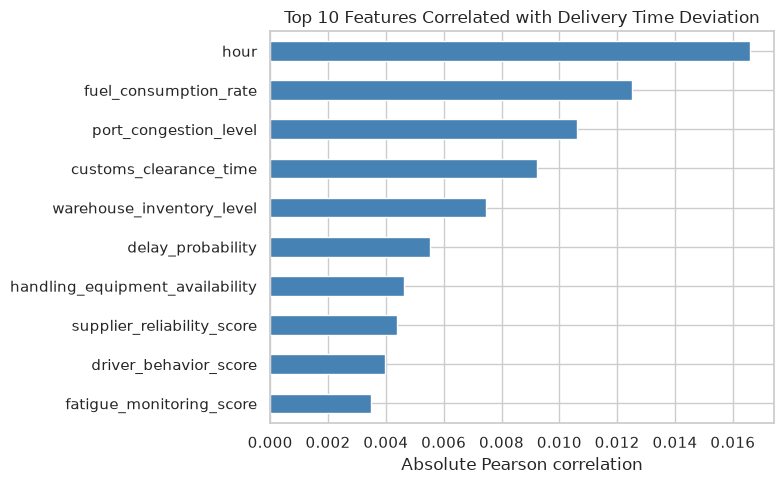

hour                              0.017
fuel_consumption_rate             0.012
port_congestion_level             0.011
customs_clearance_time            0.009
warehouse_inventory_level         0.007
delay_probability                 0.006
handling_equipment_availability   0.005
supplier_reliability_score        0.004
driver_behavior_score             0.004
fatigue_monitoring_score          0.003
Name: delivery_time_deviation, dtype: float64

In [36]:
# Step 13b — Top correlations with delivery deviation
target_corr = (
    corr['delivery_time_deviation']
    .drop('delivery_time_deviation')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
target_corr.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Pearson correlation')
plt.title('Top 10 Features Correlated with Delivery Time Deviation')
plt.tight_layout()
plt.show()
target_corr


**Part 13 후:** 스키마, 분포, 도메인 플롯, 위험 label, 상관관계까지 전체 EDA를 완료했습니다.
Part 14는 **실무 프로젝트**(읽기 전용)와 연결합니다.


---

# Part 14 — 실무 사용 사례(읽기 및 참고)

> **이 섹션에는 코드가 없습니다.** 탐색적 분석 후 실무자가 유사 데이터셋을 적용하는 방법을 보여줍니다.
> capstone 프로젝트나 Module 8 고급 실습 계획에 활용하세요.

## 1. 위험 평가 및 중단 탐지를 위한 예측 모델링

**문제:** 운영팀은 지연이 고객에게 전파되기 전 조기 경보가 필요합니다.

**이 데이터셋이 돕는 방법:**

- **Features:** traffic, weather, port congestion, supplier reliability, route risk, fatigue scores.
- **Targets:** `risk_classification`, `disruption_likelihood_score`, `delay_probability`.
- **Techniques:** gradient boosting, random forests, `timestamp` 기준 temporal cross-validation.

**Further reading:**

- [Scikit-learn — Classification overview](https://scikit-learn.org/stable/supervised_learning.html)
- [Imbalanced-learn — Handling class imbalance](https://imbalanced-learn.org/)
- *supply chain disruption prediction* 관련 논문(검색: "machine learning supply chain disruption")

---

## 2. 지연 최소화를 위한 경로 및 스케줄 최적화

**문제:** 혼잡과 ETA 변화를 고려해 지각을 최소화하는 경로와 dispatch window 선택.

**이 데이터셋이 돕는 방법:**

- **GPS**, **traffic_congestion_level**, **eta_variation_hours**를 **delivery_time_deviation**에 연결.
- `port_congestion_level` 급증 시 rerouting what-if 분석 지원.

**Further reading:**

- [OR-Tools — Vehicle routing](https://developers.google.com/optimization/routing)
- [VRP literature survey](https://arxiv.org/list/cs.AI/recent) (검색: "vehicle routing problem")

---

## 3. 물류 차량 예측 정비

**문제:** 계획外 고장은 SLA miss와 긴급 운송 비용을 유발.

**이 데이터셋이 돕는 방법:**

- `fuel_consumption_rate` 이상은 엔진·타이어 문제 신호일 수 있음.
- GPS + timestamp에서 mileage·idle time 파생 후 정비 window와 결합.

**Further reading:**

- [Predictive maintenance overview — Microsoft Azure Architecture Center](https://learn.microsoft.com/en-us/azure/architecture/guide/analytics/predictive-maintenance)
- ISO 14224 / fleet telematics vendor 문서(센서 표준)

---

## 4. 교통·날씨 등 외부 요인이 배송 시간에 미치는 영향

**문제:** 통제 가능한 지연(도크 staffing)과 통제 불가 충격(폭풍, gridlock) 분리.

**이 데이터셋이 돕는 방법:**

- `weather_condition_severity`, `traffic_congestion_level`을 `delivery_time_deviation`과 비교.
- interaction term(weather × region) 회귀 모델 구축.

**Further reading:**

- [NOAA climate data](https://www.ncei.noaa.gov/) — 실제 weather feed 조인
- [HERE Traffic API](https://developer.here.com/products/traffic) / TomTom Traffic documentation

---

## 5. 창고 및 재고 관리 실무 개선

**문제:** stockout과 과잉 재고 모두 margin을 해침; 장비 병목은 throughput을 늦춤.

**이 데이터셋이 돕는 방법:**

- `warehouse_inventory_level`, `historical_demand`, `order_fulfillment_status` 연관.
- 낮은 `handling_equipment_availability`와 높은 `loading_unloading_time`이 겹치는 행 flag.

**Module 8 hands-on:** `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb`로 계속 —
이 CSV에서 Neo4j 그래프 구축.

**Further reading:**

- [Neo4j supply chain use cases](https://neo4j.com/use-cases/supply-chain-management/)
- APICS / CSCP 재고 정책(safety stock, reorder point)

---

## 6. 물류 효율 및 위험 관리를 위한 머신러닝

**문제:** 리더십은 예측·최적화·위험 모니터링을 아우르는 통합 analytics layer를 원함.

**이 데이터셋이 돕는 방법:**

- fleet, warehouse, supplier, risk 도메인을 아우르는 **현실적 feature space** 제공.
- EDA(이 노트북) → feature store → train → deploy → drift monitor end-to-end 워크플로 지원.

**Further reading:**

- [MLOps overview — Google Cloud](https://cloud.google.com/architecture/mlops-continuous-delivery-and-automation-pipelines-in-machine-learning)
- [Kaggle dataset page](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset) — community notebooks

### 이 노트북 이후 권장 학습 경로

1. **Classification lab** — scikit-learn으로 `risk_classification` 예측.
2. **Regression lab** — `delivery_time_deviation` 예측.
3. **Graph lab** — `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb`.
4. **GraphRAG evaluation** — KG 구축 후 `Module_8_Evaluating_GraphRAG_with_RAGAS.ipynb`.


---

# Part 15 — 마무리

## 학습 내용

| Topic | Takeaway |
|-------|----------|
| Schema | fleet, warehouse, supplier, IoT, risk 도메인 26열 |
| Time | 2021–2024 시간별 기록; 계절성·피크 시간 효과 가능 |
| Quality | 공개 CSV에 결측 없음; 프로덕션 파이프라인에서는 항상 재확인 |
| Risk | 불균형 `risk_classification`; 적절한 ML 지표(F1, PR-AUC) 사용 |
| Relationships | traffic, weather, supplier 신호가 delay·disruption 점수와 동행 |

## 핵심 용어

- **ETA variation** — 계획 대비 갱신된 도착 시간의 차이.
- **Lead time** — 주문부터 입고까지 공급업체 소요 일수.
- **Fulfillment status** — 재고로', 'order_fulfillment_status' — 고객 주문이 재고에서 얼마나 충족되는지.
- **Disruption likelihood** — 복합 운영 위험 점수.

## 이해 확인

1. 창고 통제 밖 **외부** 요인을 설명하는 열 세 개를 말하세요.
2. 위험 triage용 **분류 타깃**으로 어떤 열을 쓰겠습니까?
3. `risk_classification`의 클래스 불균형이 모델 평가에 왜 중요합니까?
4. GPS 열로 **지역**별 지표 집계에 어떻게 활용할 수 있습니까?

## 관련 Module 8 자료

| Resource | Purpose |
|----------|---------|
| `data/DATASETS.md` | 다운로드 안내 및 데이터셋 카탈로그 |
| `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb` | 그래프 기반 창고 분석 |
| `Module_8_Building_Knowledge_Graphs_with_LLMs.ipynb` | 텍스트 코퍼스에서 LLM 추출 |
| `NEO4J_SETUP.md` | 그래프 실습용 데이터베이스 설정 |

---

*노트북 끝 — 물류 및 공급망 데이터셋 탐색*
